# Result Summary Analysis


## Configuration & Constants
Set your filtering and visualization preferences here. To filter for specific stages, change `STAGES_TO_INCLUDE` from `None` to a list like `['1', '2']`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns
import os
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))          # shared helpers, one level up

# Plotting helpers live next to this notebook
from vis_helper import (plot_rule_stage_heatmap, plot_patient_fingerprint,
                        plot_rule_metric_scatter, plot_rule_metric_scatter_interactive,
                        plot_metric_vs_abundance)

# Shared loader + rule-name cleaning (also used by result_summary_rule_space.ipynb)
import data_helper as dh
from data_helper import base_items, clean_items, check_rule_overlap, METADATA_COLS


In [3]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Data Filtering
USE_FUNCTIONAL_MARKERS = False
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}

RULE_MAX_ITEMS = 2
NO_SELF = True
ORGANS_TO_INCLUDE = None # e.g., ['Colon', 'Duodenum'] or None for all
STAGES_TO_INCLUDE = None # e.g., ['1', '2'] or None for all
SCORE_COLUMN = 'Pathological score' # Options: 'Pathological score', 'Clinical score'

# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.
# Heatmap Settings
TOP_N_RULES = 30
TOP_N_PER_FOV = 10
HEATMAP_CMAP = "YlOrRd"
STAGE_ORDER = ['Control_S', 'Control', 'Mild', 'Severe']  # left-to-right stage column order

# --- Splitting the rules by biopsy metadata (one heatmap per organ, per column) ---
# METADATA_COLS comes from data_helper: days after transplant, donor type, cortico
# response, survival. FOVs with no value for a column are dropped for that column -
# 27 FOVs have no Cortico Response recorded. Groups too small to read are dropped
# here; add any value to drop it from both the counts and the denominator, for example
# 'Pathological score': ['Control_S'].
DROP_VALUES = {'Donor type': ['MMUD']}   # 4 FOVs from one biopsy

# Left-to-right column order: controls first, then lightest to heaviest. Anything not
# named here keeps its place after the ones that are.
METADATA_ORDER = {
    'Days after Transplant grouped': ['Control_S', 'Control', '<30', '30-100', '>100'],
    'Donor type':            ['Control_S', 'Control', 'Sibling', 'MUD', 'Haplo'],
    'Cortico Response':      ['Control_S', 'Control', 'Responder', 'Non-responder'],
    'Survival at follow-up': ['Control_S', 'Control', 'Survived', 'Not survived'],
}


## Load Data


In [4]:
# Load cells, FOVs and biopsies (shared loader, see data_helper.py).
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


In [5]:
# Load the mined rules, same table and filtering as the rule-space notebook.
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS)


Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 4117 rules (max_items=2, kind=attracts).


In [6]:
def print_cell_count(df_results, df_cells):
     cell_counts = df_cells.groupby(['fov','cell type']).size()
     print(cell_counts.sort_values(ascending=False).to_string())

print_cell_count(df_results, df_cells)


fov                     cell type         
Control_Colon_03_FOV_6  Goblet                1940
Control_Colon_04_FOV_5  Muscle                1632
Control_09_FOV_2        Bcell                 1605
Control_Colon_03_FOV_5  Goblet                1459
                        Fibroblast            1325
Control_Colon_04_FOV_6  Macrophage            1296
                        Fibroblast            1277
GVHD_09_FOV_3           Muscle                1262
Control_Colon_04_FOV_5  Macrophage            1256
GVHD_51_FOV_3           Epithelial            1247
Control_Colon_02_FOV_5  Goblet                1231
GVHD_57_FOV_4           Epithelial            1228
Control_06_FOV_2        Epithelial            1187
Control_Colon_01_FOV_6  Epithelial            1172
Control_Colon_04_FOV_6  Epithelial            1156
Control_Colon_01_FOV_6  Goblet                1124
Control_Colon_01_FOV_7  Muscle                1117
GVHD_60_FOV_1           Epithelial            1095
GVHD_08_FOV_1           Muscle         

## Helper Methods
These methods are used to clean, aggregate, and plot the rules.


In [7]:
def find_top_rules(df_results, top_n=5):
    """
    Scores and ranks rules within a group using a normalized weighted sum of
    Support, Lift, Confidence, Conviction, and Global Count.
    Drops duplicates to keep only the absolute strongest instance of each rule.
    NO_SELF filtering is applied once upstream in `aggregate_top_rules`.
    """
    df = df_results.copy()

    # --- Define Your Weights Here ---
    w_lift = 0.15
    w_support = 0.4
    w_conf = 0.15
    w_conv = 0.2
    w_count = 0.1
    max_score = w_lift + w_support + w_conf + w_conv + w_count

    # 1. Create a scoring column for Conviction to preserve the original 'inf' values
    df['Conviction_Scoring'] = df['Conviction']
    is_inf_mask = np.isinf(df['Conviction_Scoring'])
    
    df['Conviction_Scoring'] = df['Conviction_Scoring'].replace([np.inf, -np.inf], np.nan)
    max_finite_conv = df['Conviction_Scoring'].max()
    
    artificial_inf = max_finite_conv * 1.5
    df.loc[is_inf_mask, 'Conviction_Scoring'] = artificial_inf
    df['Conviction_Scoring'] = df['Conviction_Scoring'].fillna(artificial_inf)

    # 2. Normalize metrics globally across all rows (no groupby!)
    metrics_to_scale = ['Support', 'Lift', 'Confidence', 'Conviction_Scoring', 'Rule_Count_Global']
    df['Support_n'] = df['Support']
    df['Conf_n'] = df['Confidence']
    df['Lift_n'] = 1.0 - (1.0 / df['Lift'].clip(lower=1.0))
    df['Conv_n'] = 1.0 - (1.0 / df['Conviction'].clip(lower=1.0))
    df['Count_log'] = np.log1p(df['Rule_Count_Global'])
    df['Count_n']   = df['Count_log'] / df['Count_log'].max() if df['Count_log'].max() > 0 else 0
    
    # Calculate percentiles for display
    for m in metrics_to_scale:
        display_name = m if m != 'Conviction_Scoring' else 'Conviction'
        df[f'{display_name}_pct'] = df[m].rank(pct=True) * 100

    # 3. Calculate Weighted Score for EVERY row
    df['Significance_Score'] = (
        (df['Support_n'] * w_support) +
        (df['Lift_n'] * w_lift) + 
        (df['Conf_n'] * w_conf) + 
        (df['Conv_n'] * w_conv) + 
        (df['Count_n'] * w_count) 
    )
    
    # 4. Sort by score, then drop duplicates to keep only the absolute best FOV per rule
    df = df.sort_values(by='Significance_Score', ascending=False)
    best_rules_df = df.drop_duplicates(subset=['Antecedents', 'Consequents'], keep='first')
    
    # 5. Extract Top N
    top_rules = best_rules_df.head(top_n)
    return top_rules, max_score


In [8]:
def aggregate_top_rules(df_results, df_metadata, score_col, top_n=5, no_self=True,
                        organs=None, stages=None, id_col='FOV'):
    """
    Extracts top N rules per FOV, cleans the names, and aggregates prevalence by stage.
    Rules are counted by `id_col` unique values: 'FOV' (default), 'Biopsy', or 'PatientID'.
    `organs` / `stages` optionally restrict the analysis (None = all).
    Returns (df_agg, df_metadata, rule_fovs, df_merged):
      - rule_fovs maps Clean_Rule -> its FOVs; df_merged = per-(rule x FOV) rows with metrics.
    """
    results_filtered = df_results.copy()
    if organs is not None:
        df_metadata = df_metadata[df_metadata['Organ'].isin(organs)]
        results_filtered = results_filtered[results_filtered['FOV'].isin(df_metadata['FOV'])].copy()

    if stages is not None:
        df_metadata = df_metadata[df_metadata[score_col].isin(stages)]
        results_filtered = results_filtered[results_filtered['FOV'].isin(df_metadata['FOV'])].copy()

    # NO_SELF: drop rules where a cell type repeats anywhere in the rule, once, before scoring.
    if no_self:
        def _has_overlap(row):
            try:
                ant = ast.literal_eval(row['Antecedents'])
                con = ast.literal_eval(row['Consequents'])
                return bool(check_rule_overlap(ant, con))
            except Exception:
                return False
        results_filtered = results_filtered[~results_filtered.apply(_has_overlap, axis=1)].copy()

    # A FOV where no rule survived is not part of the denominator: it could not have
    # shown any rule, so counting it would flatten every percentage.
    df_metadata = df_metadata[df_metadata['FOV'].isin(results_filtered['FOV'])]

    top_rules_list = []
    for fov, group in results_filtered.groupby('FOV'):
        top_rules, max_score = find_top_rules(group, top_n=top_n)
        top_rules_list.append(top_rules)
    
    if not top_rules_list:
        return pd.DataFrame(), df_metadata, pd.Series(dtype=object), pd.DataFrame()

    df_top = pd.concat(top_rules_list, ignore_index=True)
    
    # Canonical rule name, on both tables.
    for frame in (df_top, results_filtered):
        frame['Clean_Ant'] = frame['Antecedents'].apply(clean_items)
        frame['Clean_Con'] = frame['Consequents'].apply(clean_items)
        frame['Clean_Rule'] = frame['Clean_Ant'] + " -> " + frame['Clean_Con']
    
    # Top-N per FOV only picks WHICH rules to show. The numbers below then count every
    # row of those rules left in the results table, not only the top-N rows.
    selected = set(df_top['Clean_Rule'])
    rows = results_filtered[results_filtered['Clean_Rule'].isin(selected)].copy()

    # Attach the counting unit (and score) fresh from metadata via each rule's FOV.
    # Never drop 'FOV' — it is the merge key.
    meta_cols = ['FOV', score_col] + ([id_col] if id_col != 'FOV' else [])
    stale = [c for c in (score_col, id_col) if c != 'FOV' and c in rows.columns]
    rows = rows.drop(columns=stale)
    df_merged = rows.merge(df_metadata[meta_cols], on='FOV', how='left')

    total_col = f'Total {id_col}'
    
    # Count total unique units per rule
    total_counts = df_merged.groupby('Clean_Rule')[id_col].nunique().rename(total_col)
    # Count unique units per rule per stage
    stage_counts = df_merged.groupby(['Clean_Rule', score_col])[id_col].nunique().unstack(fill_value=0)
    
    # Combine and sort
    df_agg = pd.concat([total_counts, stage_counts], axis=1).fillna(0).astype(int)
    df_agg = df_agg.sort_values(by=total_col, ascending=False)

    # FOVs where each rule appears (for rule-specific abundance, etc.)
    rule_fovs = df_merged.groupby('Clean_Rule')['FOV'].unique()
    
    return df_agg, df_metadata, rule_fovs, df_merged


## Heatmap Plotting
Plotting lives in `vis_helper.py` (imported above). Data prep / aggregation stays here in the notebook.


# Request #2 — Positive Pairwise Directional Rules
Below, each advisor question gets its own cell. The `show_heatmap` wrapper aggregates the
top-N rules per FOV and plots their prevalence across stages; a question is answered from
several angles by calling it with different `organs` / `score_col`.


In [9]:
def build_fov_celltype_fraction(df_cells):
    """Per-FOV composition: a fov x cell_type matrix where each FOV row sums to 1."""
    comp = df_cells.groupby(['fov', 'cell type']).size().unstack(fill_value=0)
    return comp.div(comp.sum(axis=1), axis=0)

def compute_rule_abundance(rule_fovs, side, fov_frac):
    """Mean abundance of a rule's `side` ('ant'/'con') cell type(s), averaged over the
    FOVs where the rule appears. `rule_fovs`: Series mapping Clean_Rule -> list of FOVs."""
    vals = {}
    for rule, fovs in rule_fovs.items():
        ant, con = rule.split(' -> ')
        items = (ant if side == 'ant' else con).split(', ')
        rows = fov_frac.index.intersection(list(fovs))
        sub = fov_frac.loc[rows, items]        # the rule's FOVs x the side's cell types
        vals[rule] = sub.mean(axis=1).mean()   # mean over items, then over those FOVs
    return pd.Series(vals)

FOV_FRAC = build_fov_celltype_fraction(df_cells)
print("FOV x cell-type fraction matrix:", FOV_FRAC.shape)

def canonicalize_rules(df_results):
    """All positive pairwise no-self rules as per-(rule x FOV) rows with a canonical Clean_Rule."""
    df = df_results[df_results['Lift'] > 1].copy()
    def _keep(r):
        base = base_items(r['Antecedents']) + base_items(r['Consequents'])
        return len(base) <= RULE_MAX_ITEMS and len(base) == len(set(base))
    df = df[df.apply(_keep, axis=1)].copy()
    df['Clean_Rule'] = df['Antecedents'].apply(clean_items) + " -> " + df['Consequents'].apply(clean_items)
    return df

def build_rule_table(rule_rows, df_fovs, fov_frac=None, with_abundance=False, score_col=None):
    """One row per canonical rule: median metrics, unit counts, stage, and (optional) abundance.
    `rule_rows`: per-(rule x FOV) frame with a 'Clean_Rule' column + metric columns."""
    g = rule_rows.groupby('Clean_Rule')
    metric_cols = [c for c in ['Lift', 'Confidence', 'Conviction', 'Support', 'FDR'] if c in rule_rows.columns]
    tbl = g[metric_cols].median()
    tbl.columns = ['med_' + c for c in tbl.columns]

    rule_fovs = g['FOV'].unique()
    fov_to_bio = df_fovs.set_index('FOV')['Biopsy']
    fov_to_pat = df_fovs.set_index('FOV')['PatientID']
    tbl['n_FOV'] = rule_fovs.apply(lambda f: len(set(f)))
    tbl['n_Biopsy'] = rule_fovs.apply(lambda f: fov_to_bio.reindex(list(f)).nunique())
    tbl['n_Patient'] = rule_fovs.apply(lambda f: fov_to_pat.reindex(list(f)).nunique())

    parts = tbl.index.to_series().str.split(' -> ', n=1, expand=True)
    tbl.insert(0, 'antecedent', parts[0].values)
    tbl.insert(1, 'consequent', parts[1].values)

    if score_col is not None and score_col in df_fovs.columns:
        fov_to_stage = df_fovs.set_index('FOV')[score_col]
        def _mode(f):
            s = fov_to_stage.reindex(list(f)).dropna()
            return s.mode().iloc[0] if len(s) else 'NA'
        tbl['top_stage'] = rule_fovs.apply(_mode)

    if with_abundance and fov_frac is not None:
        tbl['ant_abund'] = compute_rule_abundance(rule_fovs, 'ant', fov_frac)
        tbl['con_abund'] = compute_rule_abundance(rule_fovs, 'con', fov_frac)
    return tbl


FOV x cell-type fraction matrix: (267, 32)


In [10]:
def show_heatmap(score_col=SCORE_COLUMN, organs=None, id_col='FOV',
                 stage_order=None, show_abundance=False, show_metrics=False,
                 sort_by='prevalence', top_n=TOP_N_PER_FOV, max_rules_to_show=30, save=None,
                 drop_values=None):
    """Aggregate top rules (optionally within `organs`) and plot stage prevalence.

    `id_col`         : counting unit — 'FOV', 'Biopsy' (sample), or 'PatientID' (person).
    `show_abundance` : back-to-back antecedent/consequent abundance bars (over each rule's FOVs).
    `show_metrics`   : print a per-rule table (median Lift/Confidence/Conviction + counts, plus
                       abundance when `show_abundance`) beneath the heatmap, in the same row order.
    `sort_by`        : 'prevalence' (default) or 'ant'/'con'/'both' to order rows by abundance.
    """
    if stage_order is None:
        stage_order = STAGE_ORDER
    # Drop FOVs with no value for this column, and any group too small to read.
    meta = df_fovs.dropna(subset=[score_col])
    if drop_values:
        meta = meta[~meta[score_col].isin(drop_values)]

    df_agg, df_meta, rule_fovs, df_merged = aggregate_top_rules(
        df_results, meta, score_col=score_col, top_n=top_n, no_self=NO_SELF,
        organs=organs, id_col=id_col)

    rule_abundance = None
    if show_abundance or sort_by in ('ant', 'con', 'both'):
        rule_abundance = pd.DataFrame({
            'ant': compute_rule_abundance(rule_fovs, 'ant', FOV_FRAC),
            'con': compute_rule_abundance(rule_fovs, 'con', FOV_FRAC),
        })

    # Task 3: reorder displayed rows by abundance.
    if sort_by in ('ant', 'con', 'both'):
        key = rule_abundance['ant'] if sort_by == 'ant' else \
              rule_abundance['con'] if sort_by == 'con' else rule_abundance.mean(axis=1)
        df_agg = df_agg.loc[key.reindex(df_agg.index).sort_values(ascending=False).index]

    plot_rule_stage_heatmap(df_agg, df_meta, score_col=score_col, organs=organs, id_col=id_col,
                            stage_order=stage_order,
                            rule_abundance=(rule_abundance if show_abundance else None),
                            max_rules_to_show=max_rules_to_show, save=save)

    # Task 1: metric/abundance table beneath the heatmap, matching the displayed row order.
    if show_metrics:
        tbl = build_rule_table(df_merged, df_fovs, fov_frac=FOV_FRAC,
                               with_abundance=show_abundance, score_col=score_col)
        disp = tbl.reindex(df_agg.head(max_rules_to_show).index).round(3)
        try:
            from IPython.display import display
            display(disp)
        except Exception:
            print(disp.to_string())
    return df_agg


### Q1 + Q2 + Q4 — Shared vs condition-/patient-specific rules
The **same heatmap** answers both: read the **"Total …"** column for *how shared* a rule is,
and the **per-stage columns** for *condition-specificity*. A rule high in **FOV %** but low in
**PatientID %** is inflated by one patient's many FOVs (patient-specific, not shared).
Calls below vary the angle: counting unit, score, and organ.


saved summary_downloads\q1_prevalence_by_fov.pdf


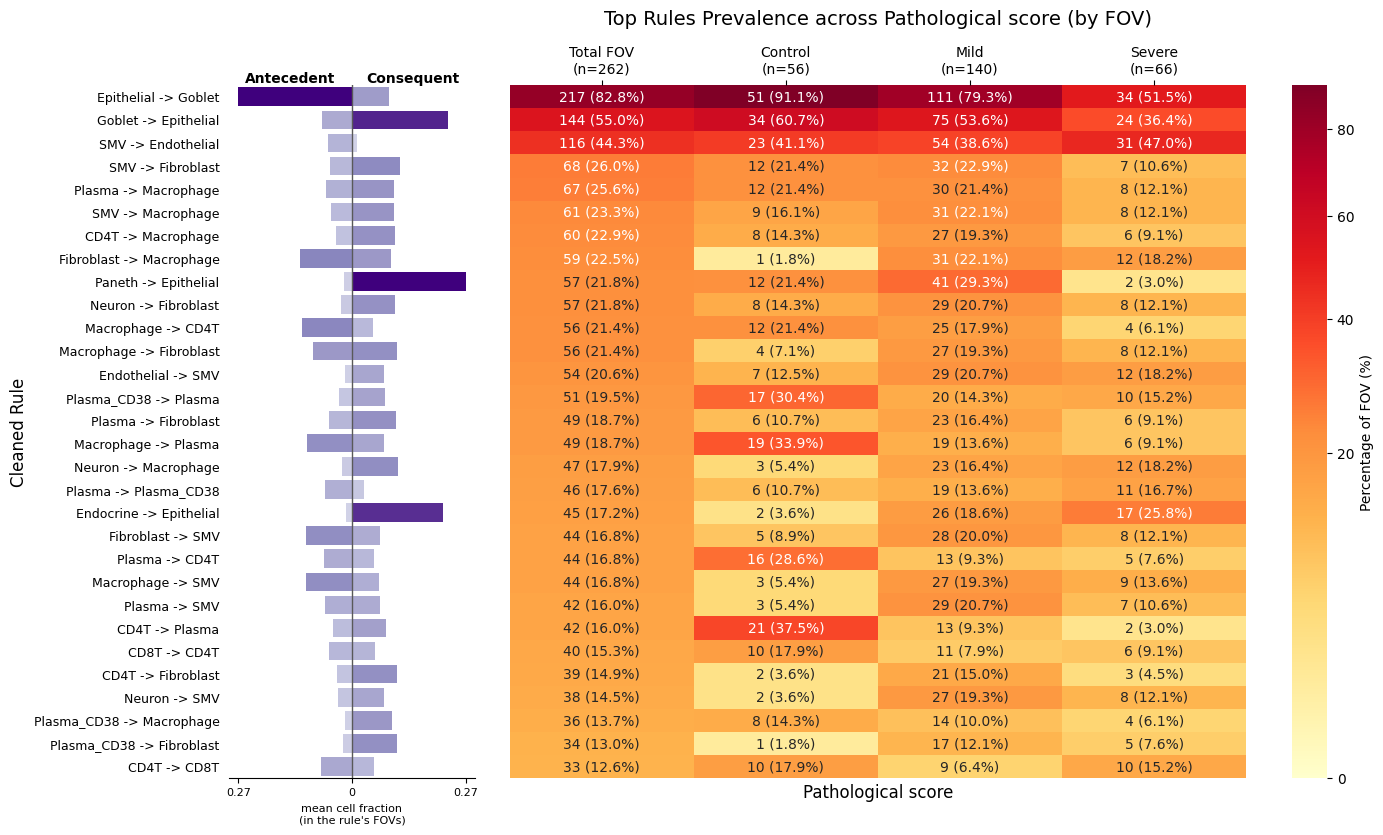

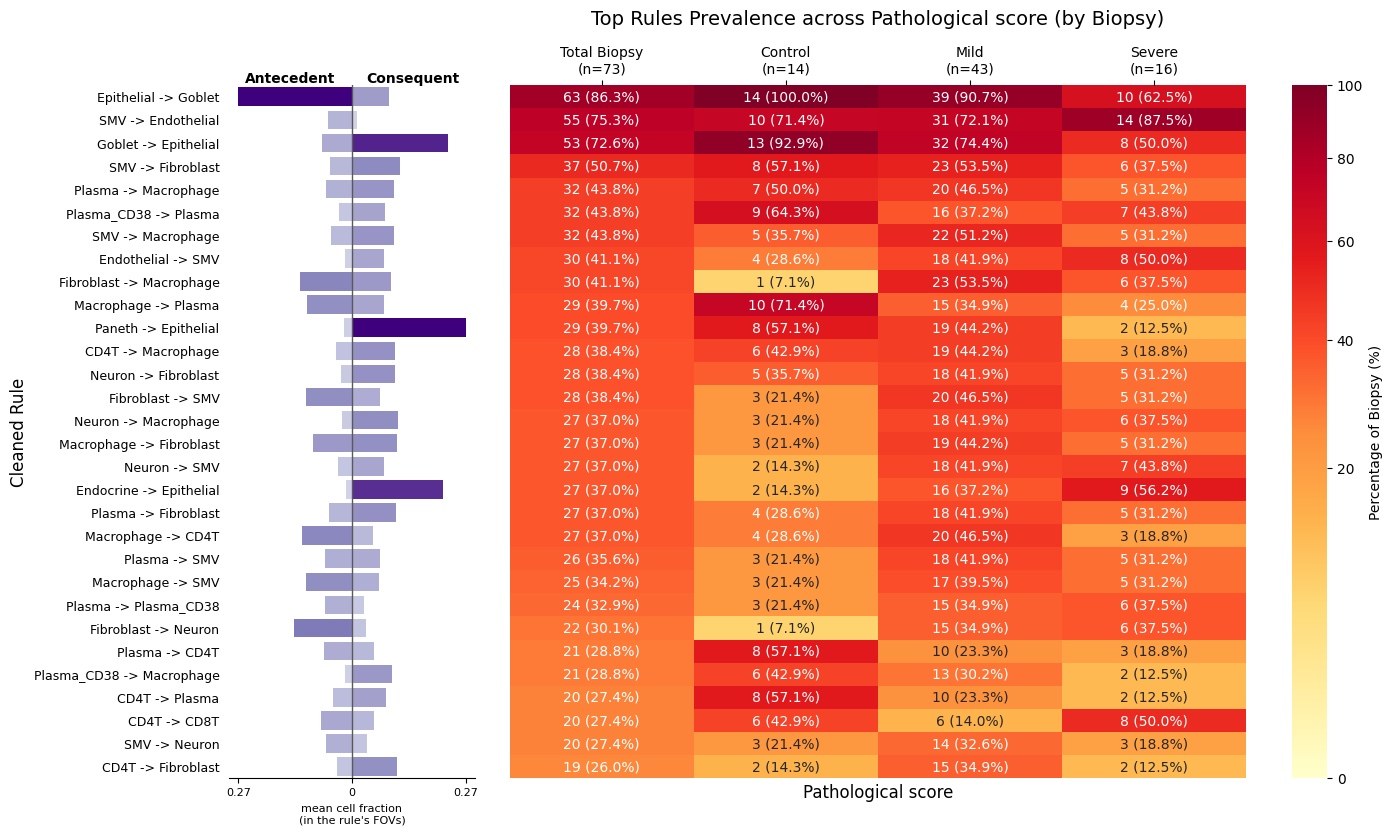

saved summary_downloads\q1_prevalence_by_patient.pdf


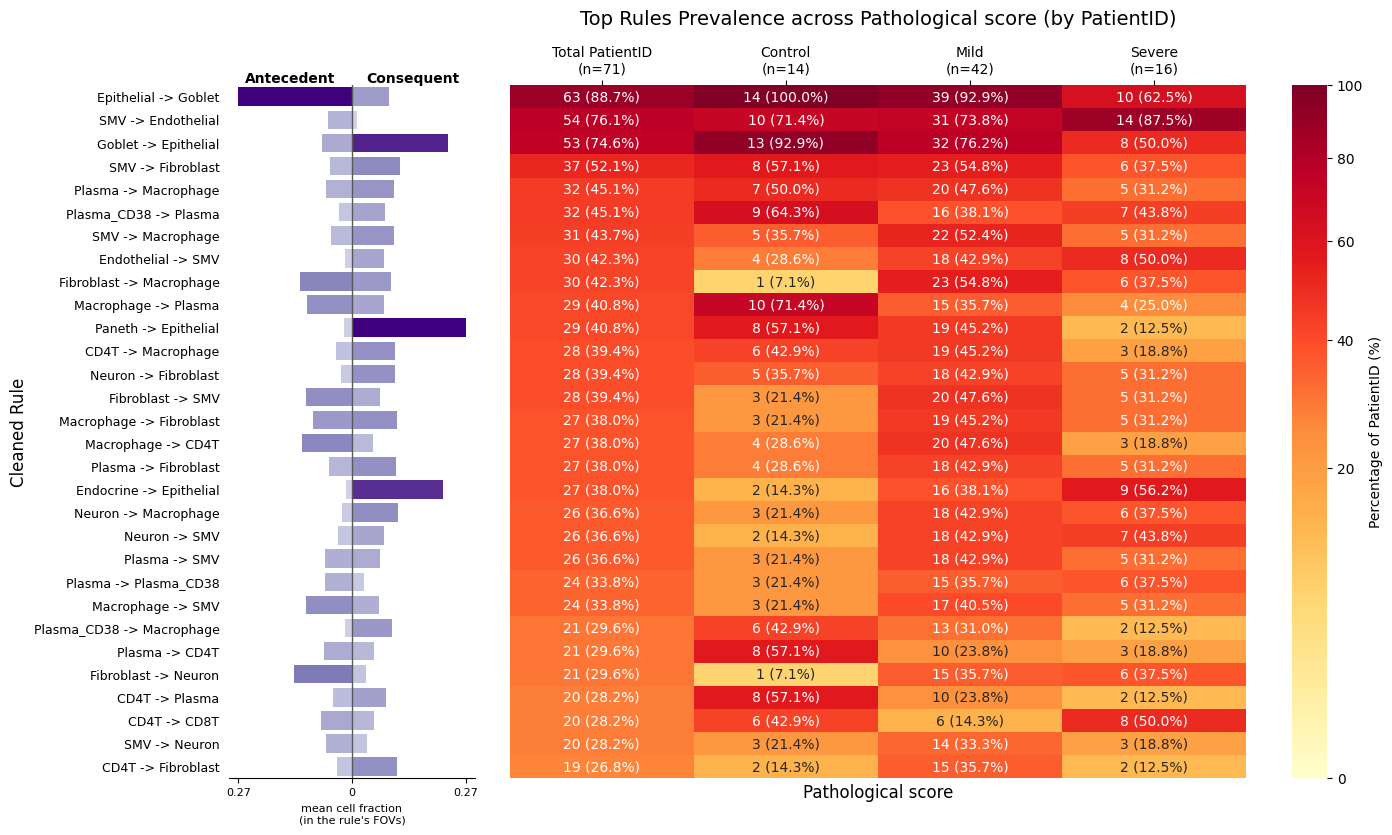

,Total PatientID,Control,Mild,Severe
Clean_Rule,,,,
Epithelial -> Goblet,63,14,39,10
SMV -> Endothelial,54,10,31,14
Goblet -> Epithelial,53,13,32,8
SMV -> Fibroblast,37,8,23,6
Plasma -> Macrophage,32,7,20,5
...,...,...,...,...
CD4T -> Goblet,1,0,1,0
Unidentified -> ImmuneOther_CD45RA,1,0,0,1
Unidentified -> Mesenchymal_VIM,1,1,0,0


In [11]:
# Counting unit: FOV inflation vs biopsy vs patient (all organs, pathological)
show_heatmap(score_col='Pathological score', id_col='FOV', show_abundance=True,
             save='q1_prevalence_by_fov')

show_heatmap(score_col='Pathological score', id_col='Biopsy', show_abundance=True)     # 77 biopsies

show_heatmap(score_col='Pathological score', id_col='PatientID', show_abundance=True,
             save='q1_prevalence_by_patient')                         # 75 patients


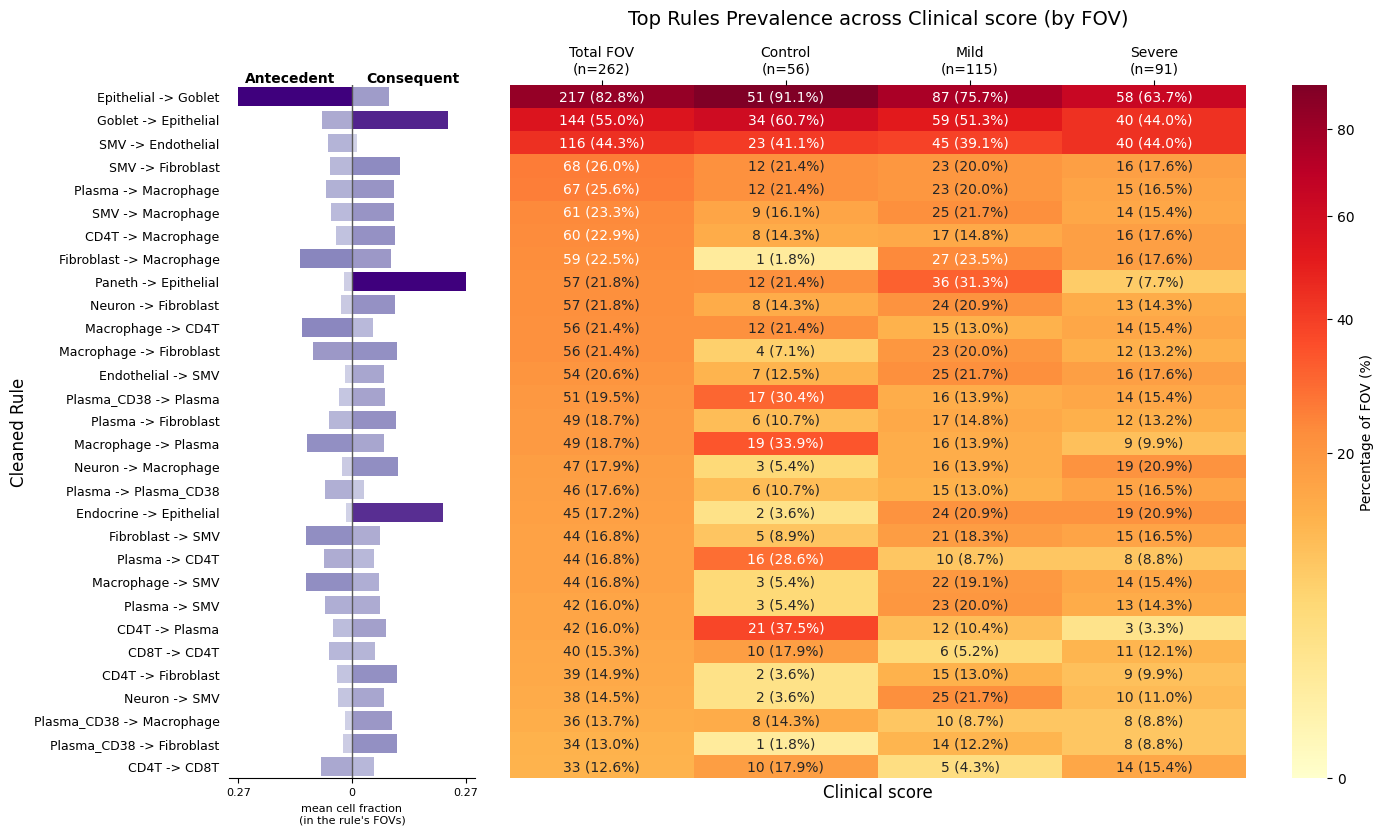

,Total FOV,Control,Mild,Severe
Clean_Rule,,,,
Epithelial -> Goblet,217,51,87,58
Goblet -> Epithelial,144,34,59,40
SMV -> Endothelial,116,23,45,40
SMV -> Fibroblast,68,12,23,16
Plasma -> Macrophage,67,12,23,15
...,...,...,...,...
CD4T -> Goblet,1,0,0,1
Unidentified -> ImmuneOther_CD45RA,1,0,1,0
Unidentified -> Mesenchymal_VIM,1,1,0,0


In [12]:

# Condition axis: clinical score (patient-level)
show_heatmap(score_col='Clinical score', id_col='FOV', show_abundance=True)


saved summary_downloads\q2_prevalence_colon.pdf


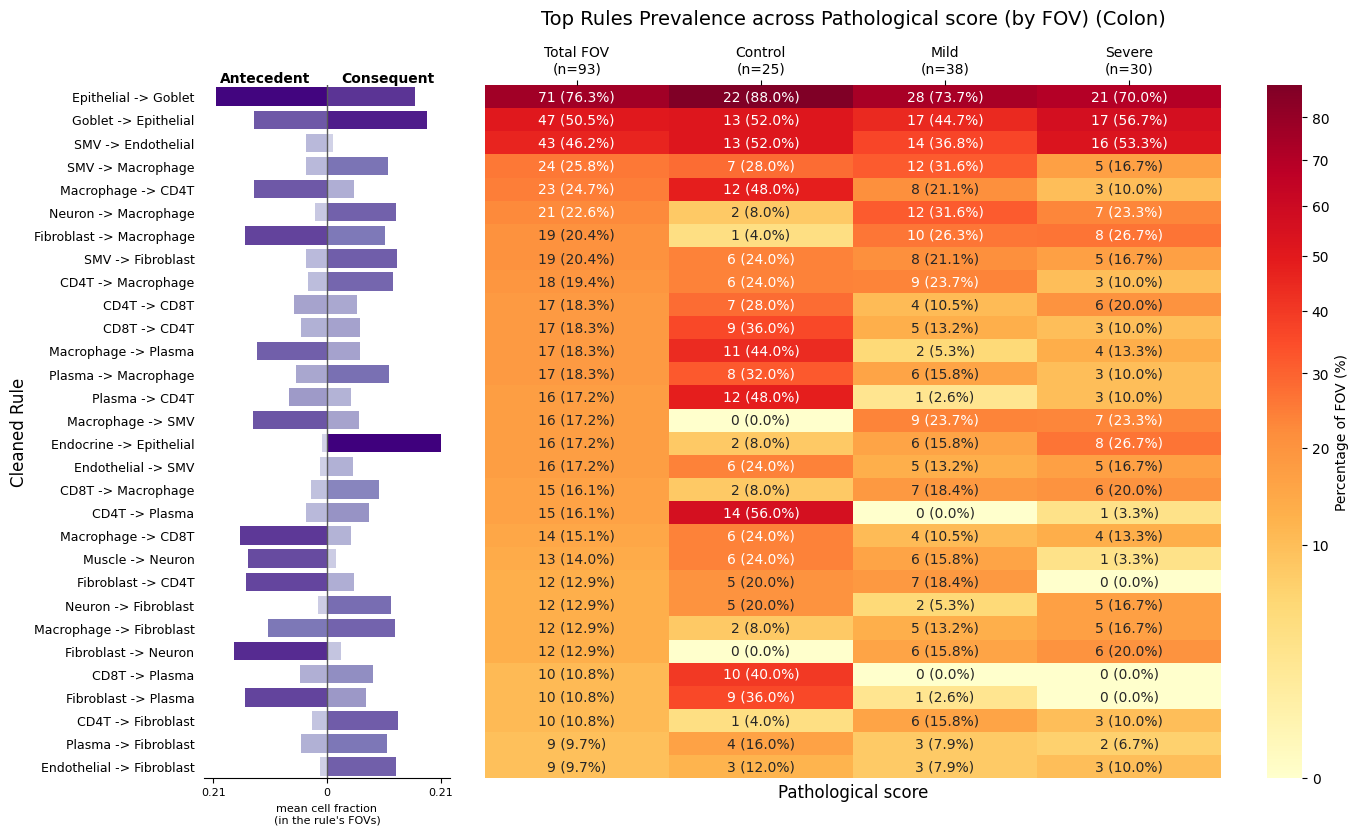

saved summary_downloads\q2_prevalence_duodenum.pdf


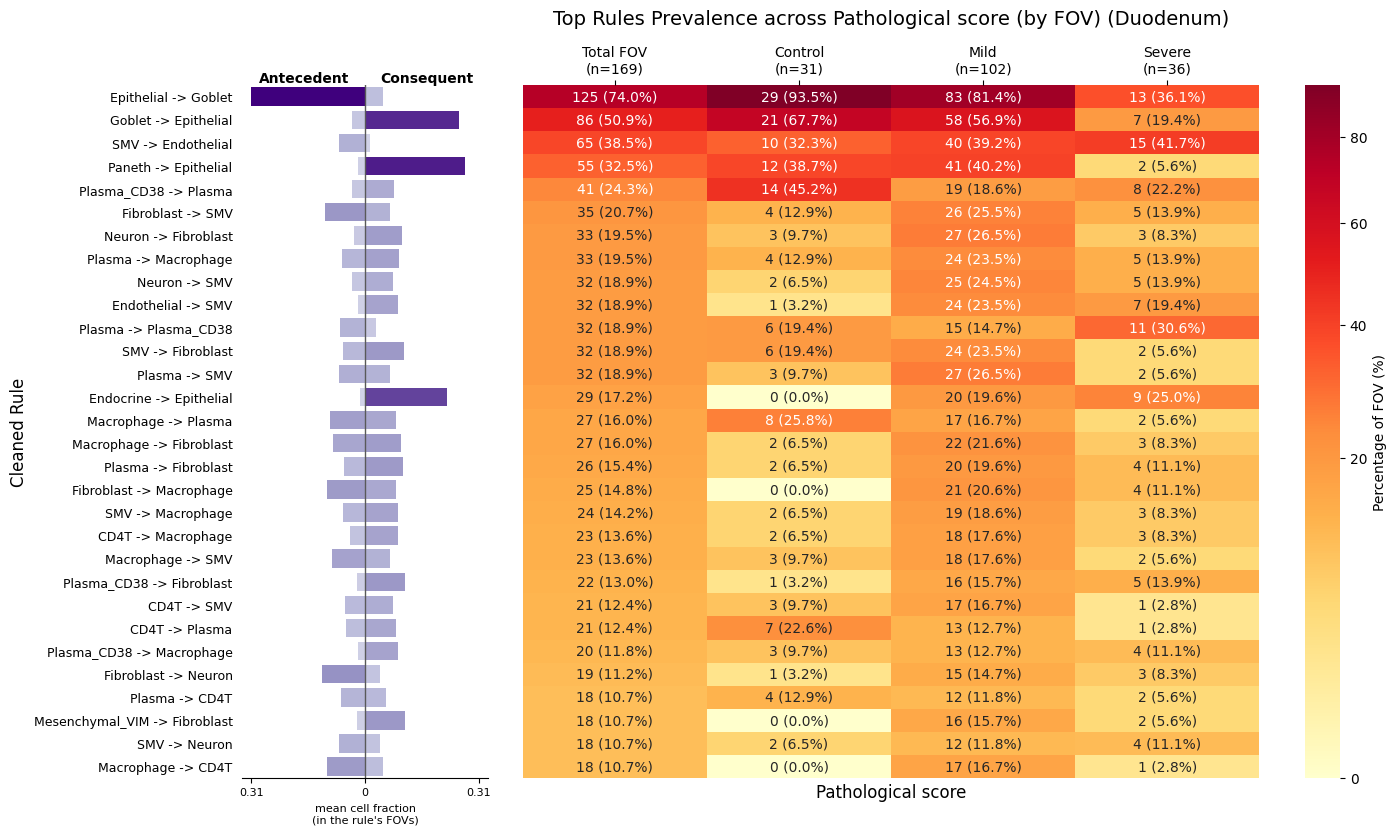

,Total FOV,Control,Mild,Severe
Clean_Rule,,,,
Epithelial -> Goblet,125,29,83,13
Goblet -> Epithelial,86,21,58,7
SMV -> Endothelial,65,10,40,15
Paneth -> Epithelial,55,12,41,2
Plasma_CD38 -> Plasma,41,14,19,8
...,...,...,...,...
Unidentified -> Fibroblast,1,0,0,1
Unidentified -> ImmuneOther_CD45RA,1,0,0,1
Unidentified -> Mesenchymal_VIM,1,1,0,0


In [13]:
# Tissue region: per organ (patient-level, pathological)
show_heatmap(score_col='Pathological score', id_col='FOV', organs=['Colon'], show_abundance=True,
             save='q2_prevalence_colon')
show_heatmap(score_col='Pathological score', id_col='FOV', organs=['Duodenum'], show_abundance=True,
             save='q2_prevalence_duodenum')


### Q4 — Which rules may just reflect cell-type abundance?
The bars beside each rule show the **mean cell fraction** of its **antecedent** (left) and
**consequent** (right) cell type, averaged **only over the FOVs where that rule appears**.
Length and color both encode abundance. A prevalent rule with **long** bars is likely
abundance-driven; one with **short** bars is a more specific spatial signal. Antecedent vs
consequent asymmetry — meaningful for directional rules — is visible at a glance. In-memory only.


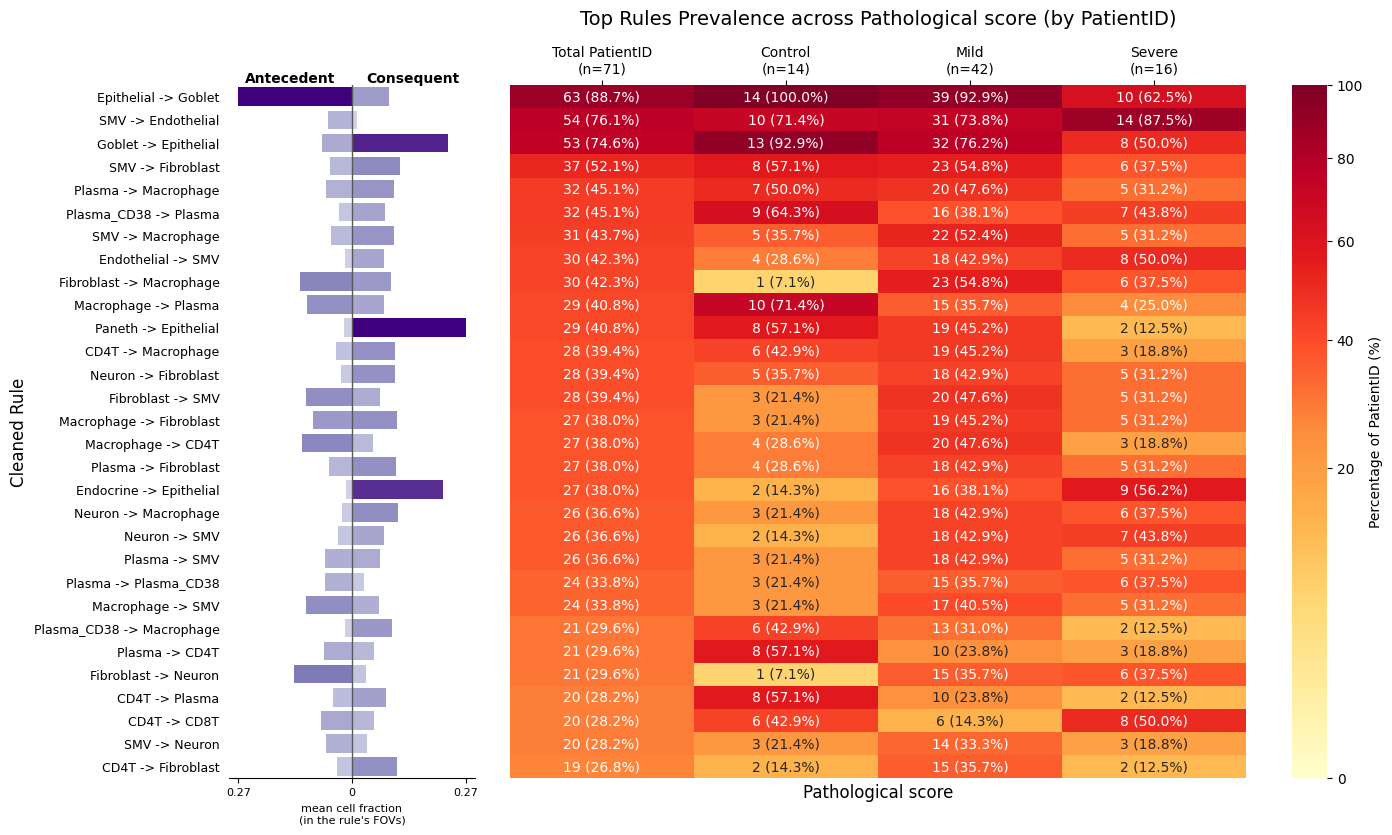

,antecedent,consequent,med_Lift,med_Confidence,med_Conviction,med_Support,n_FOV,n_Biopsy,n_Patient,top_stage,ant_abund,con_abund
Clean_Rule,,,,,,,,,,,,
Epithelial -> Goblet,Epithelial,Goblet,1.748,0.758,2.301,0.206,217,63,63,Mild,0.270,0.089
SMV -> Endothelial,SMV,Endothelial,2.407,0.598,1.811,0.031,116,55,54,Mild,0.057,0.013
Goblet -> Epithelial,Goblet,Epithelial,1.401,0.991,36.515,0.048,144,53,53,Mild,0.070,0.229
SMV -> Fibroblast,SMV,Fibroblast,1.259,0.957,5.800,0.042,68,37,37,Mild,0.051,0.114
Plasma -> Macrophage,Plasma,Macrophage,1.288,0.971,8.538,0.052,67,32,32,Mild,0.061,0.099
Plasma_CD38 -> Plasma,Plasma_CD38,Plasma,1.418,0.889,3.279,0.025,51,32,32,Mild,0.032,0.078
SMV -> Macrophage,SMV,Macrophage,1.269,0.935,3.987,0.041,61,32,31,Mild,0.049,0.100
Endothelial -> SMV,Endothelial,SMV,1.501,0.915,5.535,0.013,54,30,30,Mild,0.016,0.076
Fibroblast -> Macrophage,Fibroblast,Macrophage,1.273,0.898,2.942,0.116,59,30,30,Mild,0.122,0.093


,Total PatientID,Control,Mild,Severe
Clean_Rule,,,,
Epithelial -> Goblet,63,14,39,10
SMV -> Endothelial,54,10,31,14
Goblet -> Epithelial,53,13,32,8
SMV -> Fibroblast,37,8,23,6
Plasma -> Macrophage,32,7,20,5
...,...,...,...,...
CD4T -> Goblet,1,0,1,0
Unidentified -> ImmuneOther_CD45RA,1,0,0,1
Unidentified -> Mesenchymal_VIM,1,1,0,0


In [14]:
# Prevalence heatmap (patient-level) + back-to-back abundance bars + metric table beneath (Task 1).
show_heatmap(score_col='Pathological score', id_col='PatientID', show_abundance=True, show_metrics=True)


### Which rules each patient has
Counting a patient once tells us a rule showed up in *some* of their FOVs. This heatmap shows
**in how many**: each cell = the share of that patient's FOVs that have the rule (0 = none,
1 = all). Patients are **grouped by how similar their rules are**, and the two strips above color
each patient by **Pathological** and **Clinical** stage — so if the colors form blocks, patients
with similar rules also share a stage. A row dark for only a few patients = a rule special to
those patients; a row dark across many = a rule most people have.


In [15]:
def build_patient_fingerprint(rule_fovs, df_fovs, patient_col='PatientID', rules=None,
                              min_fovs=2):
    """Rules x patients matrix; each cell = share of that patient's FOVs that have the rule.

    Patients with fewer than `min_fovs` FOVs are left out: with one FOV every share is
    0 or 1, which says nothing about whether a rule holds across that patient.
    `rule_fovs`: Series Clean_Rule -> its FOVs (from aggregate_top_rules)."""
    fov_to_pat = df_fovs.set_index('FOV')[patient_col]
    denom = df_fovs.groupby(patient_col)['FOV'].nunique()   # each patient's FOV count (in scope)
    denom = denom[denom >= min_fovs]
    rows = {}
    for rule, fovs in rule_fovs.items():
        pats = fov_to_pat.reindex(list(fovs)).dropna()
        rows[rule] = pats.value_counts() / denom            # share per patient
    mat = pd.DataFrame(rows).T.reindex(columns=denom.index).fillna(0.0)
    if rules is not None:
        mat = mat.reindex(index=list(rules)).dropna(how='all')
    return mat

def show_fingerprint(score_col=SCORE_COLUMN, patient_col='PatientID', organs=None,
                     order='cluster', cluster_rules=False, by='patient',
                     top_n=TOP_N_PER_FOV, max_rules=30, save=None, show_consistency=False):
    """Build the rules x patients (or rules x FOVs) matrix and plot it.

    `by='patient'` : one column per patient, coloured by the share of their FOVs.
    `by='fov'`     : one column per FOV, coloured by log2 of lift, patients kept together.
    `order='cluster'` puts patients with similar rules next to each other (then the stage
    strips show whether that grouping matches stage); `order='stage'` sorts by stage instead.
    """
    df_agg, df_meta, rule_fovs, df_merged = aggregate_top_rules(
        df_results, df_fovs, score_col=score_col, top_n=top_n, no_self=NO_SELF,
        organs=organs, id_col=patient_col)
    rules = df_agg.head(max_rules).index
    if by == 'fov':
        mat = build_fov_fingerprint(df_merged, df_meta, rules=rules)
    else:
        mat = build_patient_fingerprint(rule_fovs, df_meta, patient_col=patient_col,
                                        rules=rules)
    # Among the patients that have a rule at all, the mean share of their FOVs with
    # it: near 1 the rule holds across a patient, near 0 it flickers between their FOVs.
    consistency = mat.where(mat > 0).mean(axis=1) if show_consistency else None

    plot_patient_fingerprint(mat, df_meta, score_col=score_col, consistency=consistency,
                             patient_col='FOV' if by == 'fov' else patient_col,
                             stage_order=STAGE_ORDER, order=order, cluster_rules=cluster_rules,
                             max_rules=max_rules, save=save, by=by,
                             scope=', '.join(organs) if organs else 'both organs')
    return mat


### The same fingerprint, one column per FOV

The heatmap above gives each patient one column. This one gives each **FOV** a column, with
a patient's FOVs side by side, so you can see whether a rule holds across all of someone's
FOVs or just one. The colour is **log2 of lift**: 0 means no association, above 0 the cell
types attract, below 0 they avoid. A blank cell means the rule never fired in that FOV.


In [16]:
def build_fov_fingerprint(df_merged, df_fovs, metric='Lift', rules=None, min_fovs=2):
    """Rules x FOVs, each cell log2 of that rule's metric in that FOV.

    Columns are ordered by patient, so one patient's FOVs sit together, and patients with
    fewer than `min_fovs` FOVs are left out - the point of this view is to compare a
    patient's FOVs with each other. A rule that never fired in a FOV stays blank rather
    than being filled with a neutral value."""
    mat = np.log2(df_merged.pivot_table(index='Clean_Rule', columns='FOV', values=metric))
    keep = df_fovs.groupby('PatientID')['FOV'].transform('nunique') >= min_fovs
    order = df_fovs[keep].sort_values(['PatientID', 'FOV'])['FOV']
    mat = mat.reindex(columns=[f for f in order if f in mat.columns])
    if rules is not None:
        mat = mat.reindex(index=list(rules)).dropna(how='all')
    return mat


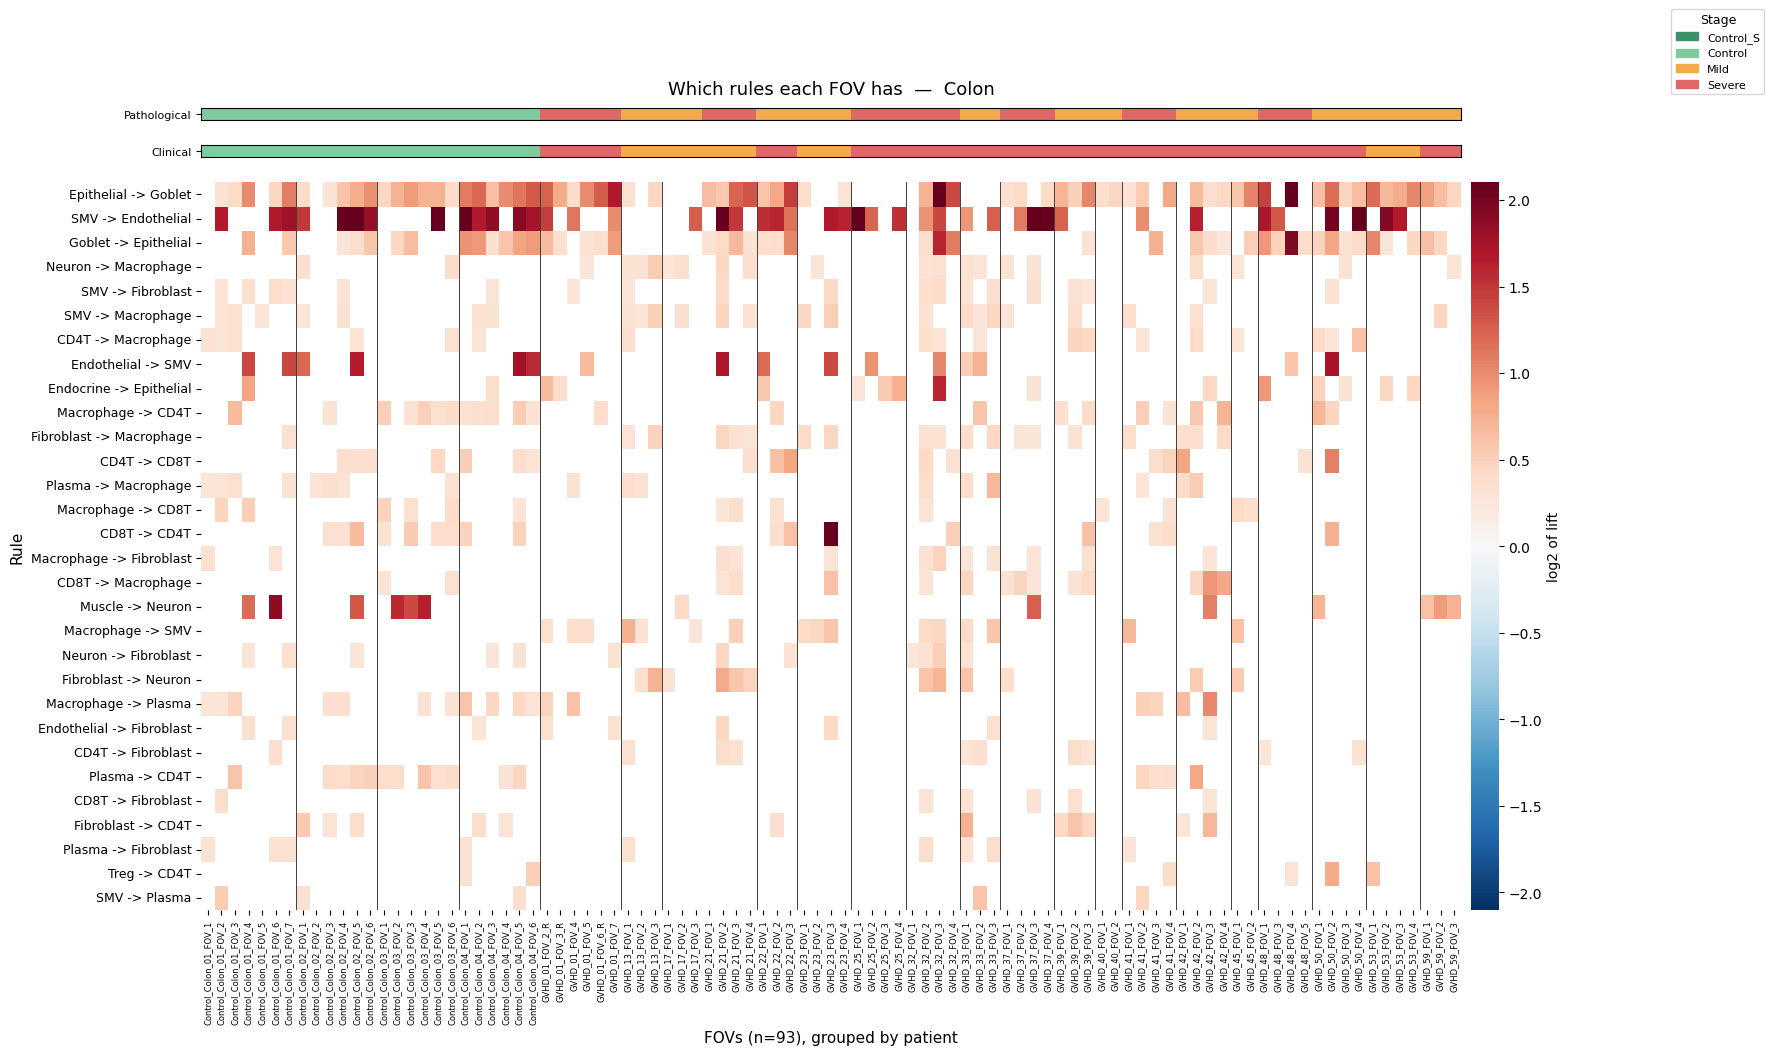

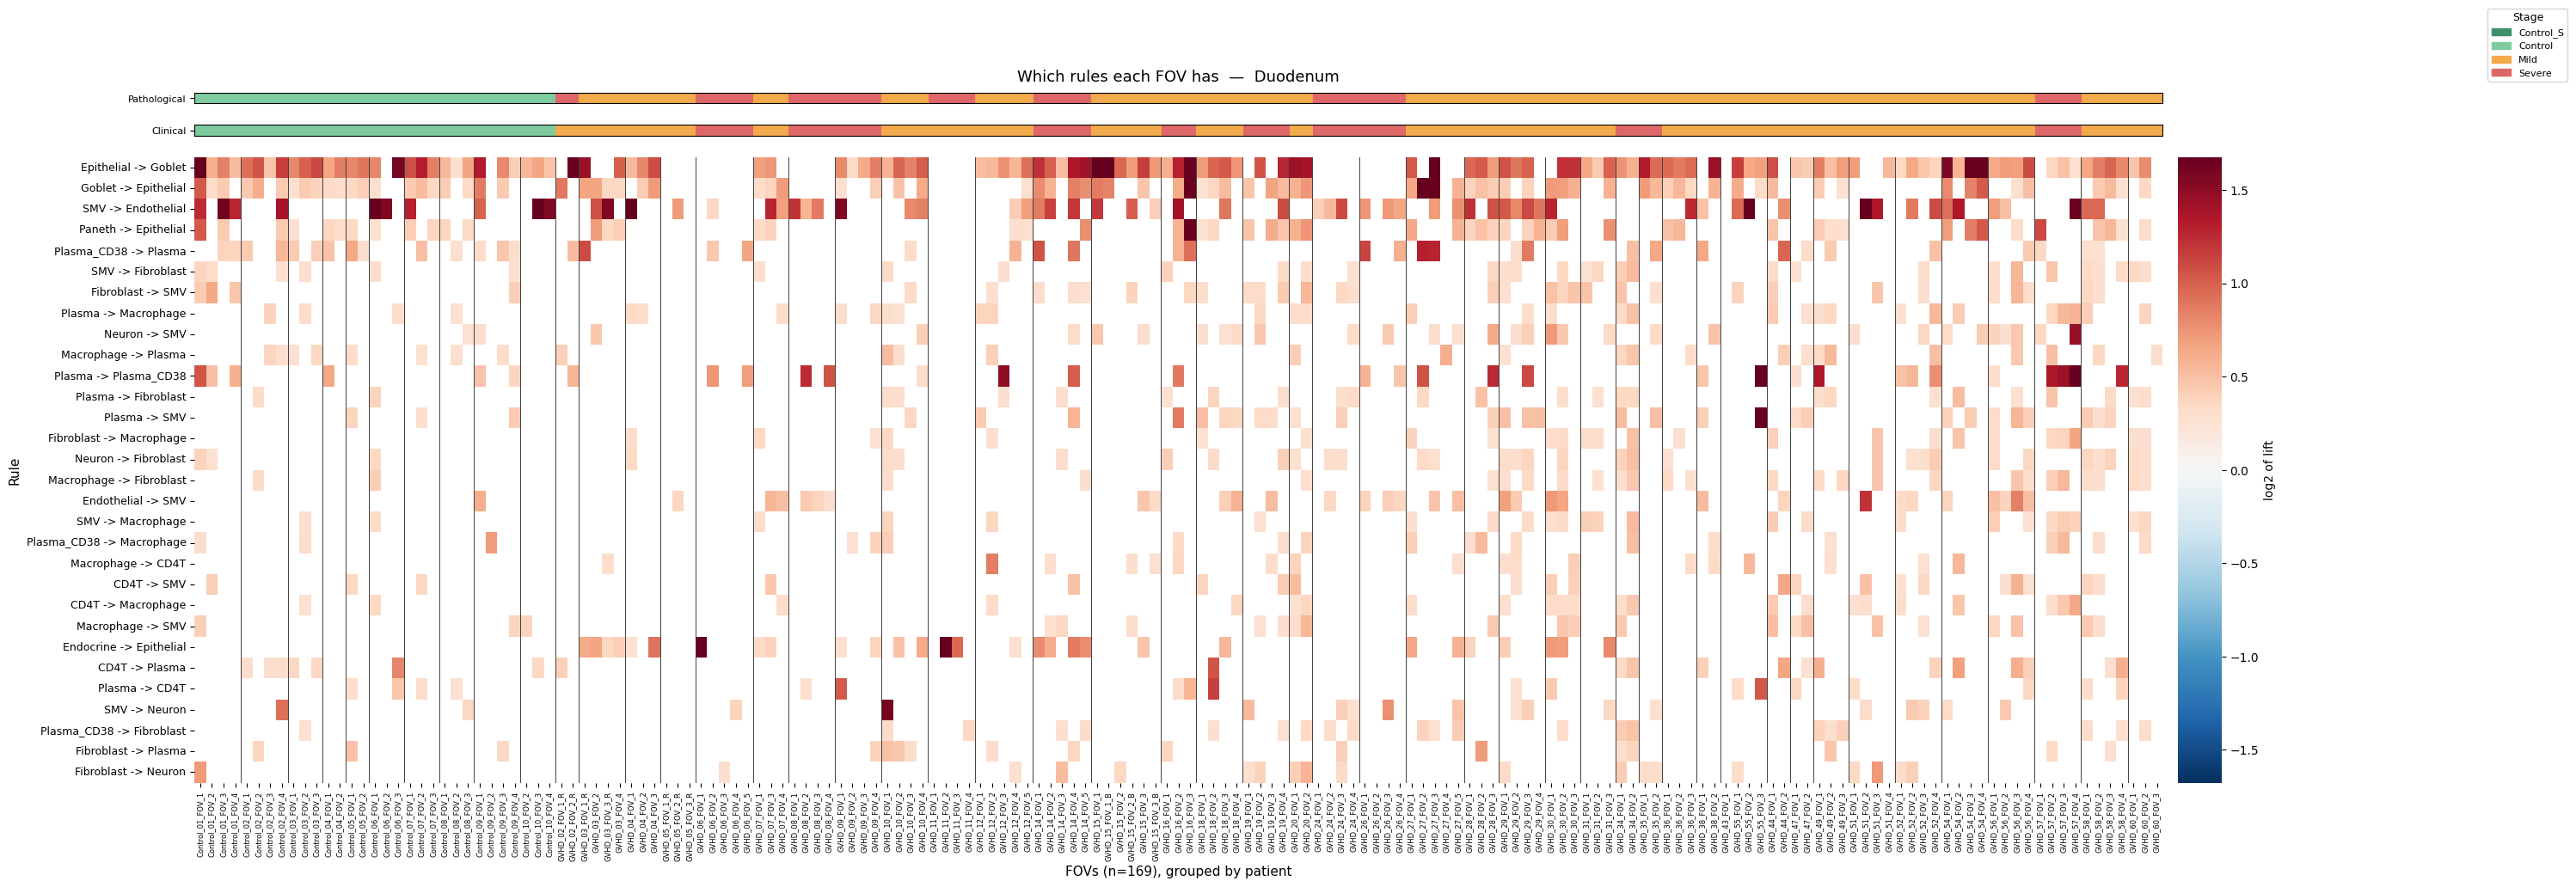

In [17]:
for organ in ['Colon', 'Duodenum']:
    show_fingerprint(score_col='Pathological score', by='fov', organs=[organ])


### Splitting the rules by biopsy metadata

The same top-rule heatmap, but the columns are a metadata group instead of a disease stage:
days after transplant, donor type, cortico response, survival. One heatmap per organ, since
the two organs carry different rules.


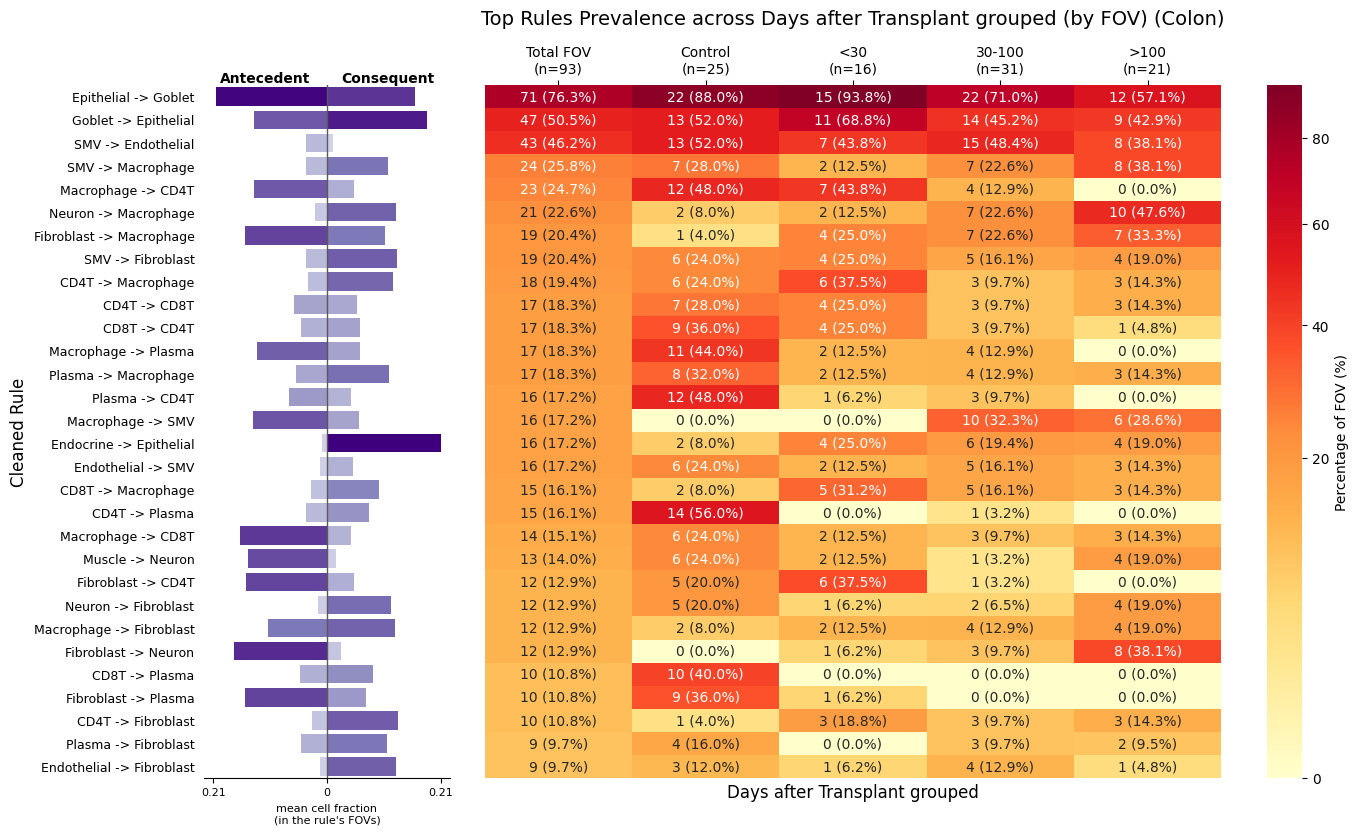

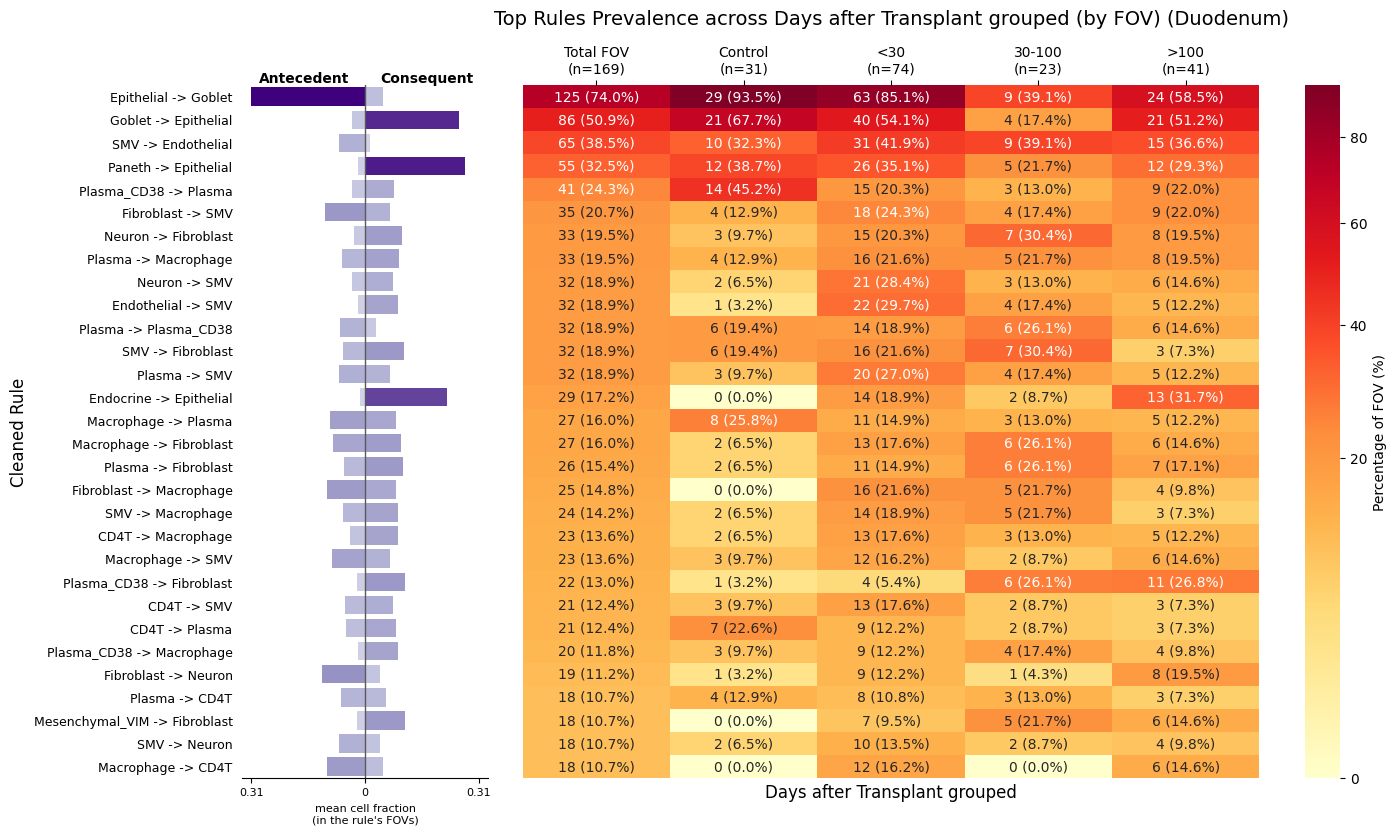

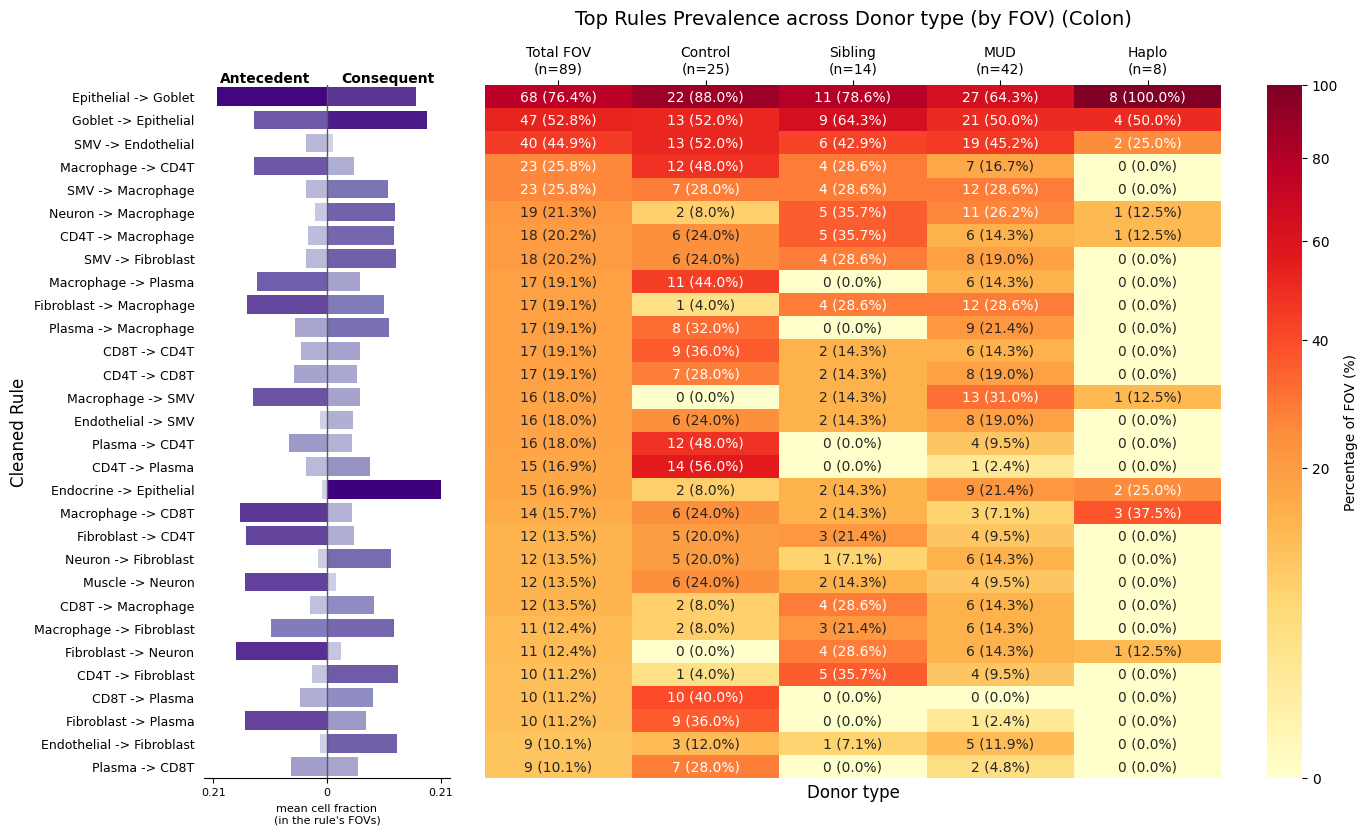

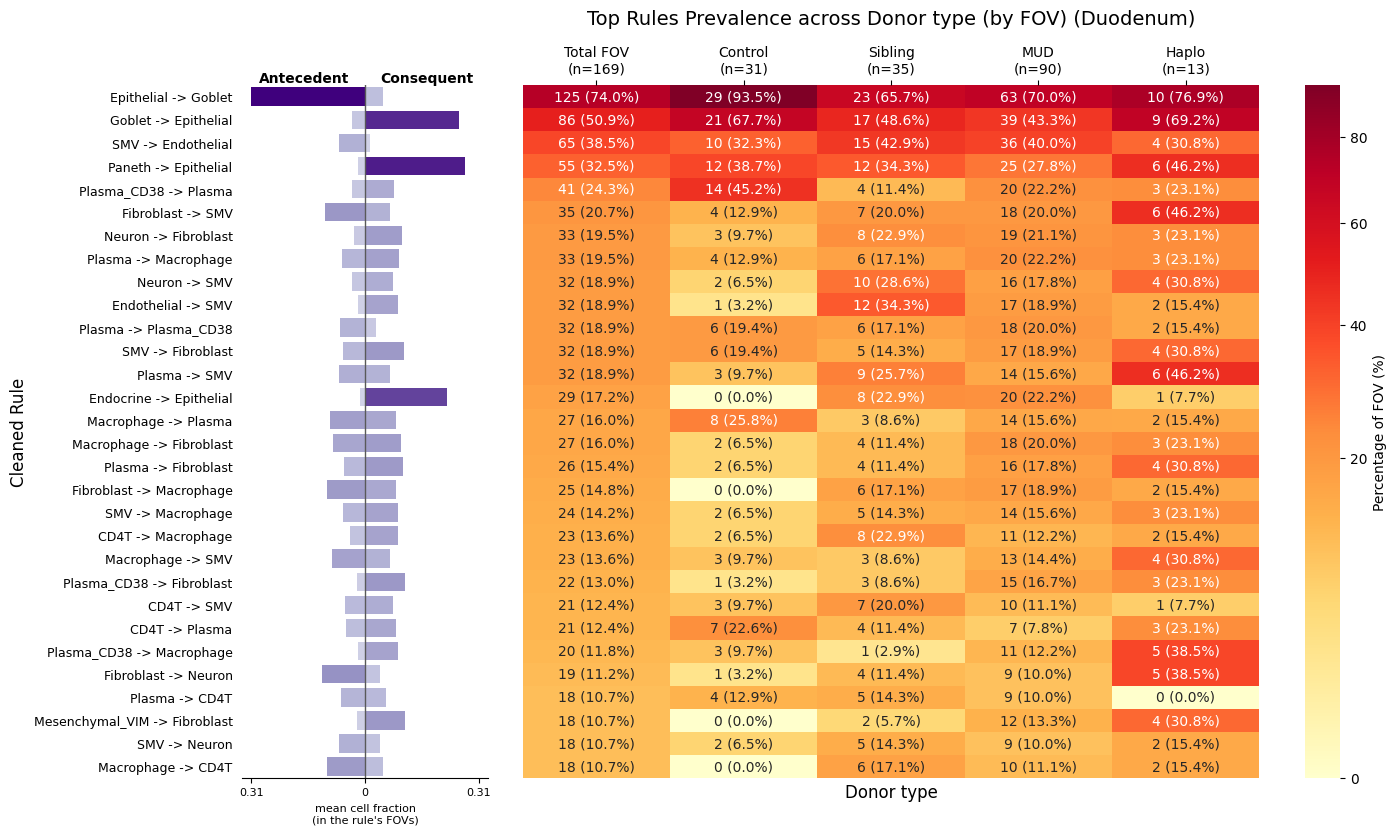

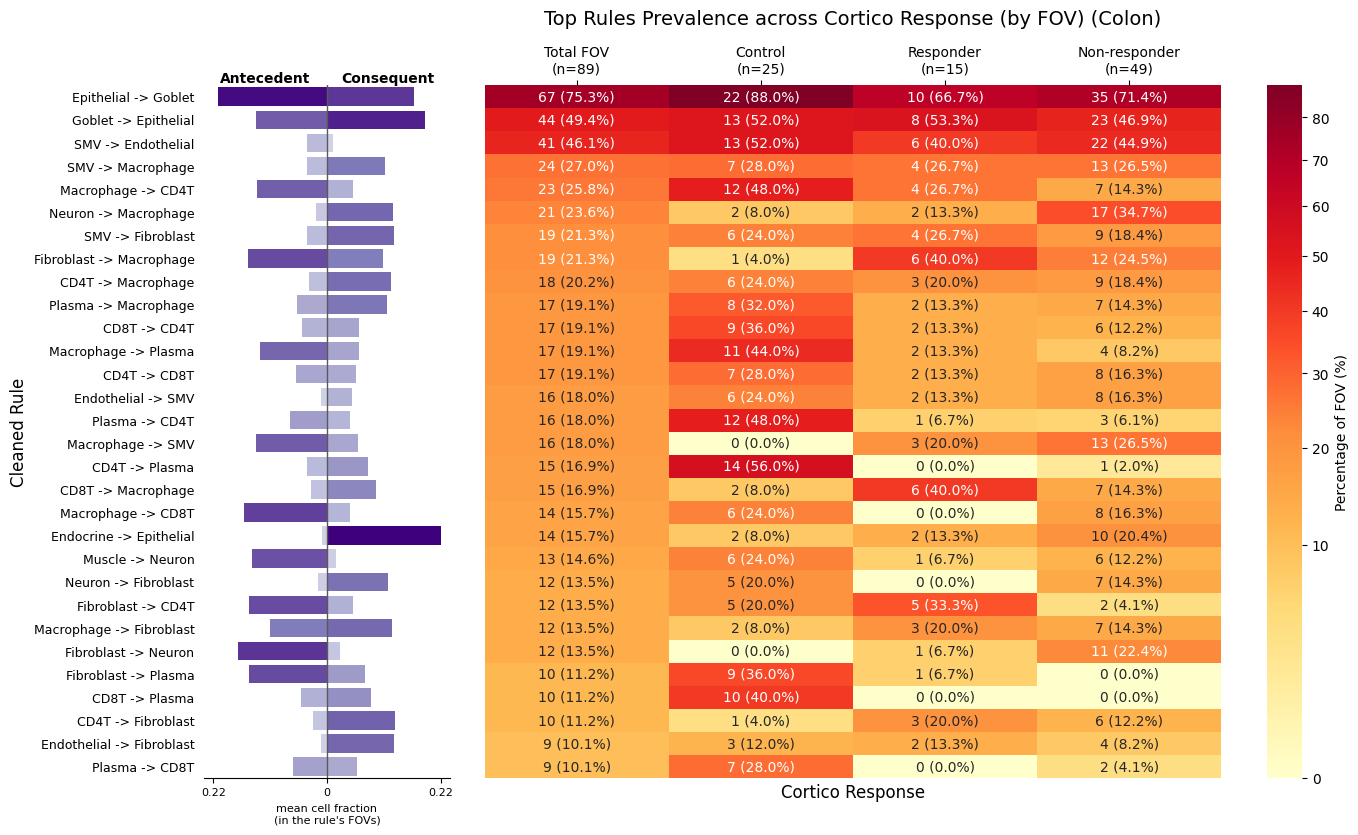

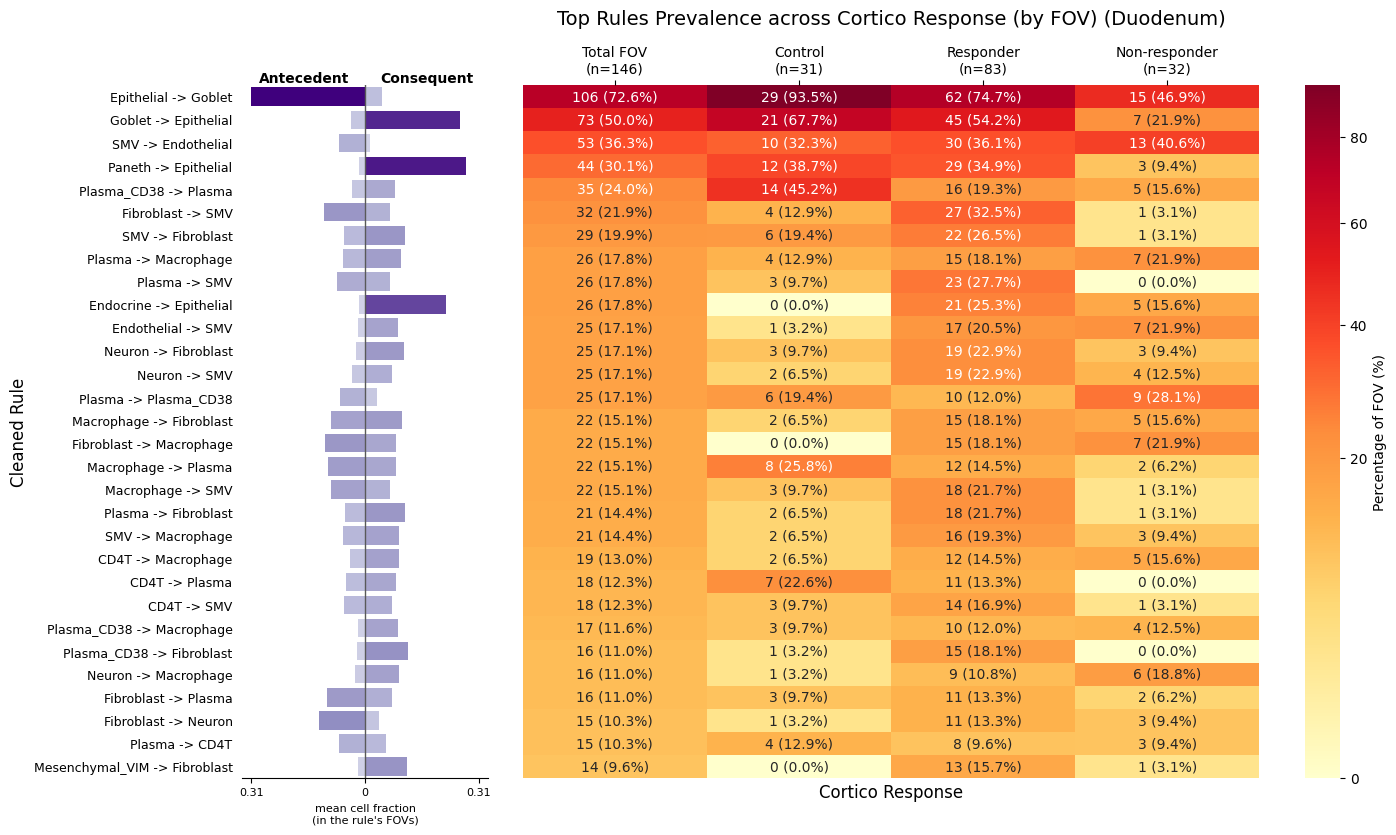

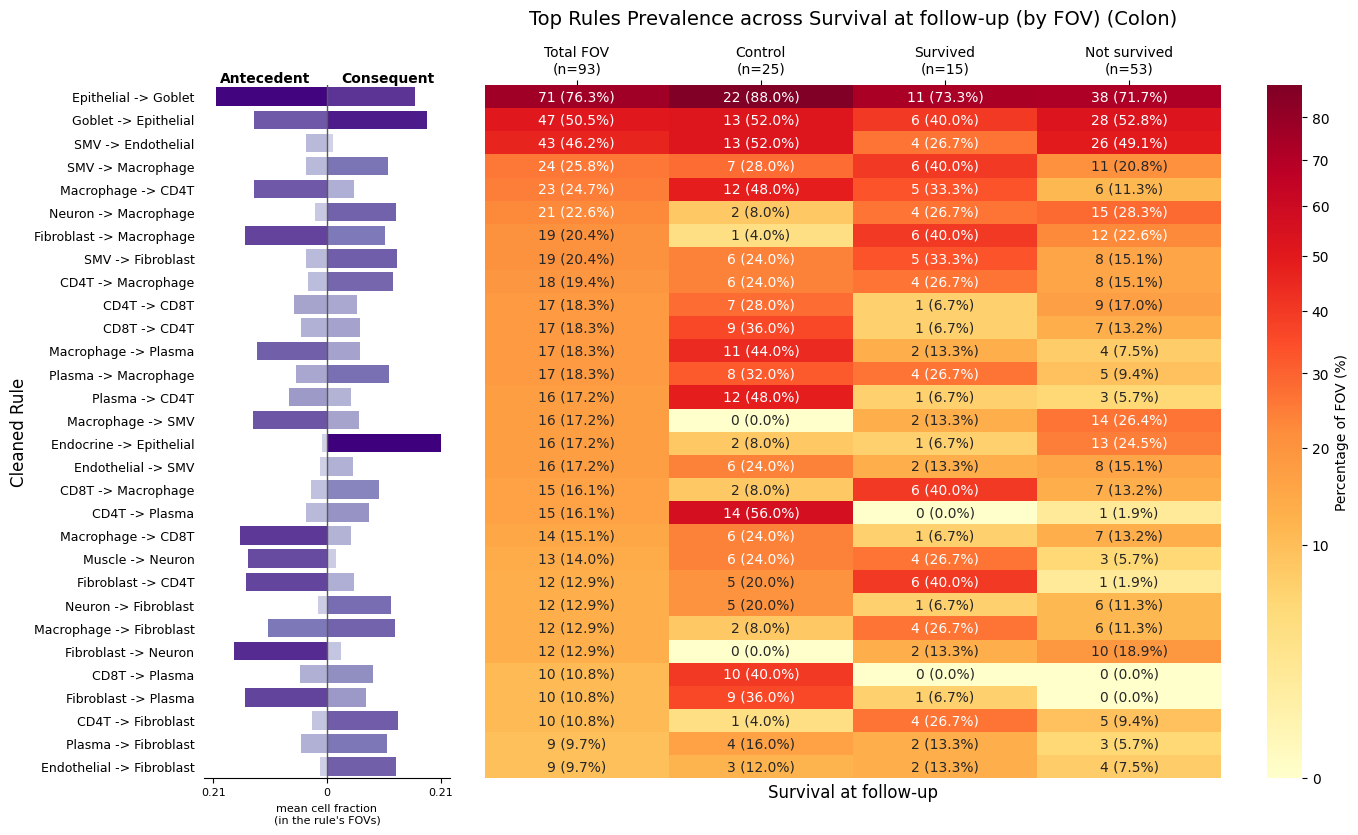

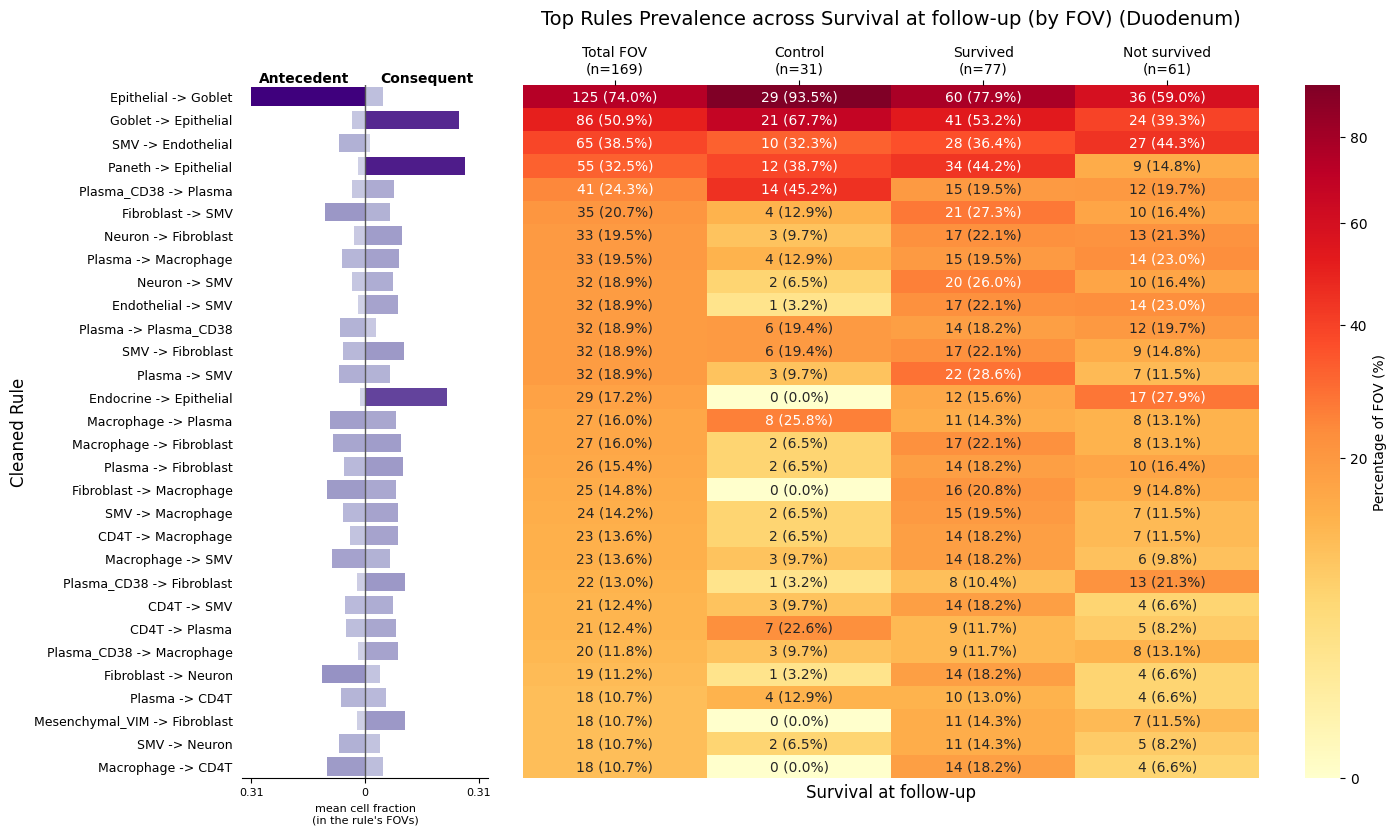

In [18]:
for col in METADATA_COLS:
    for organ in ['Colon', 'Duodenum']:
        show_heatmap(score_col=col, organs=[organ], id_col='FOV',
                     stage_order=METADATA_ORDER.get(col), show_abundance=True,
                     drop_values=DROP_VALUES.get(col))


saved summary_downloads\q2_patient_fingerprint.pdf


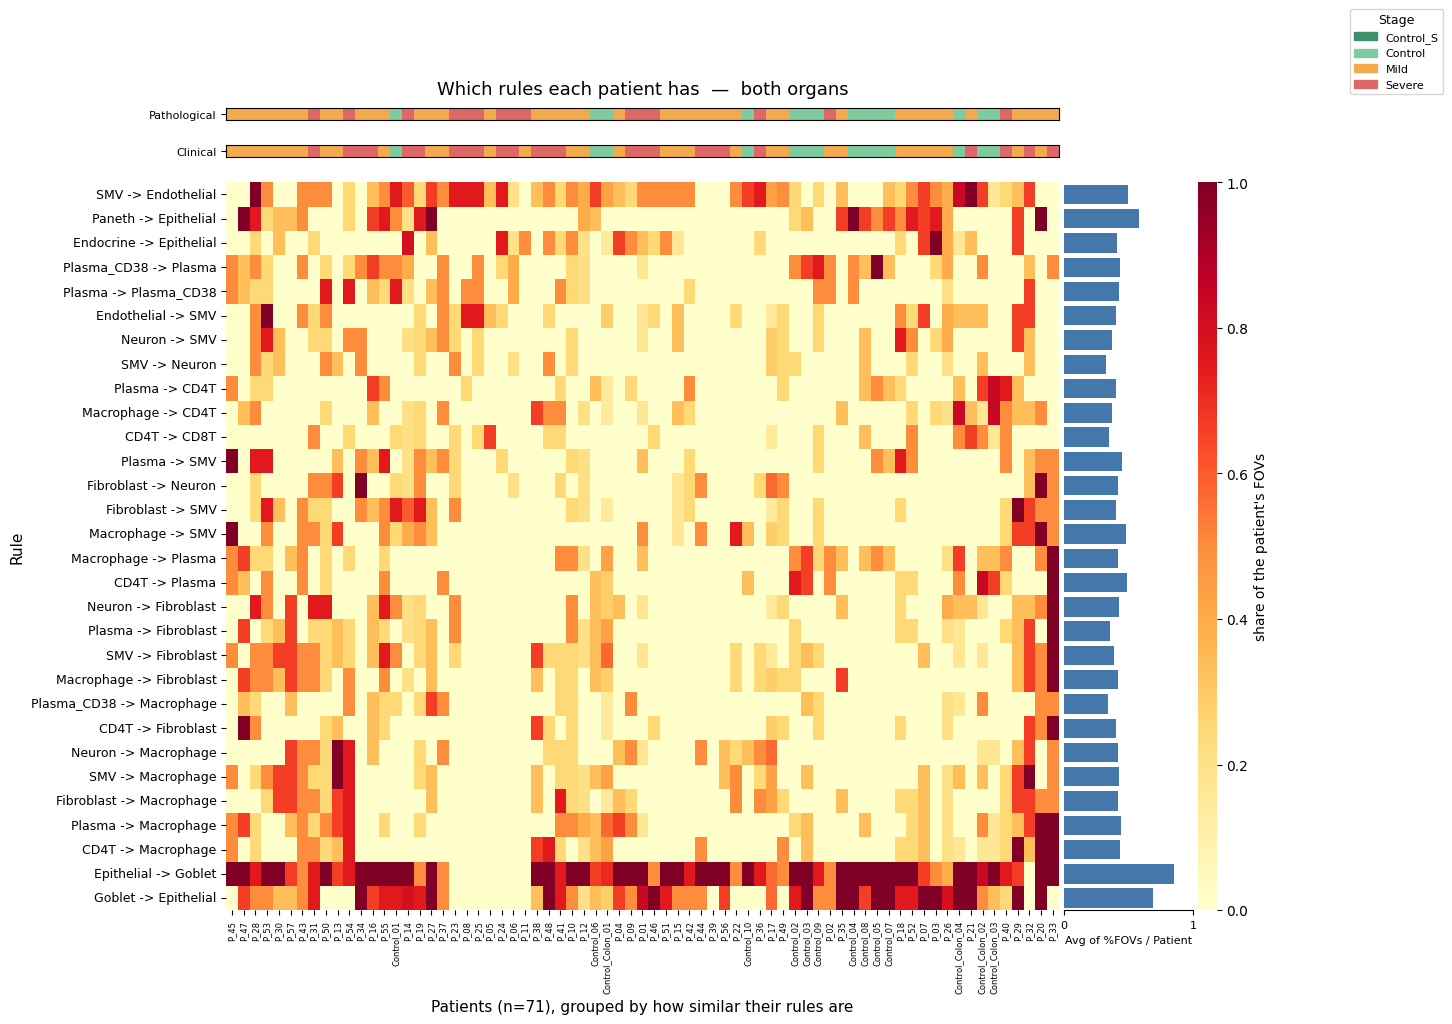

saved summary_downloads\q2_patient_fingerprint_colon.pdf


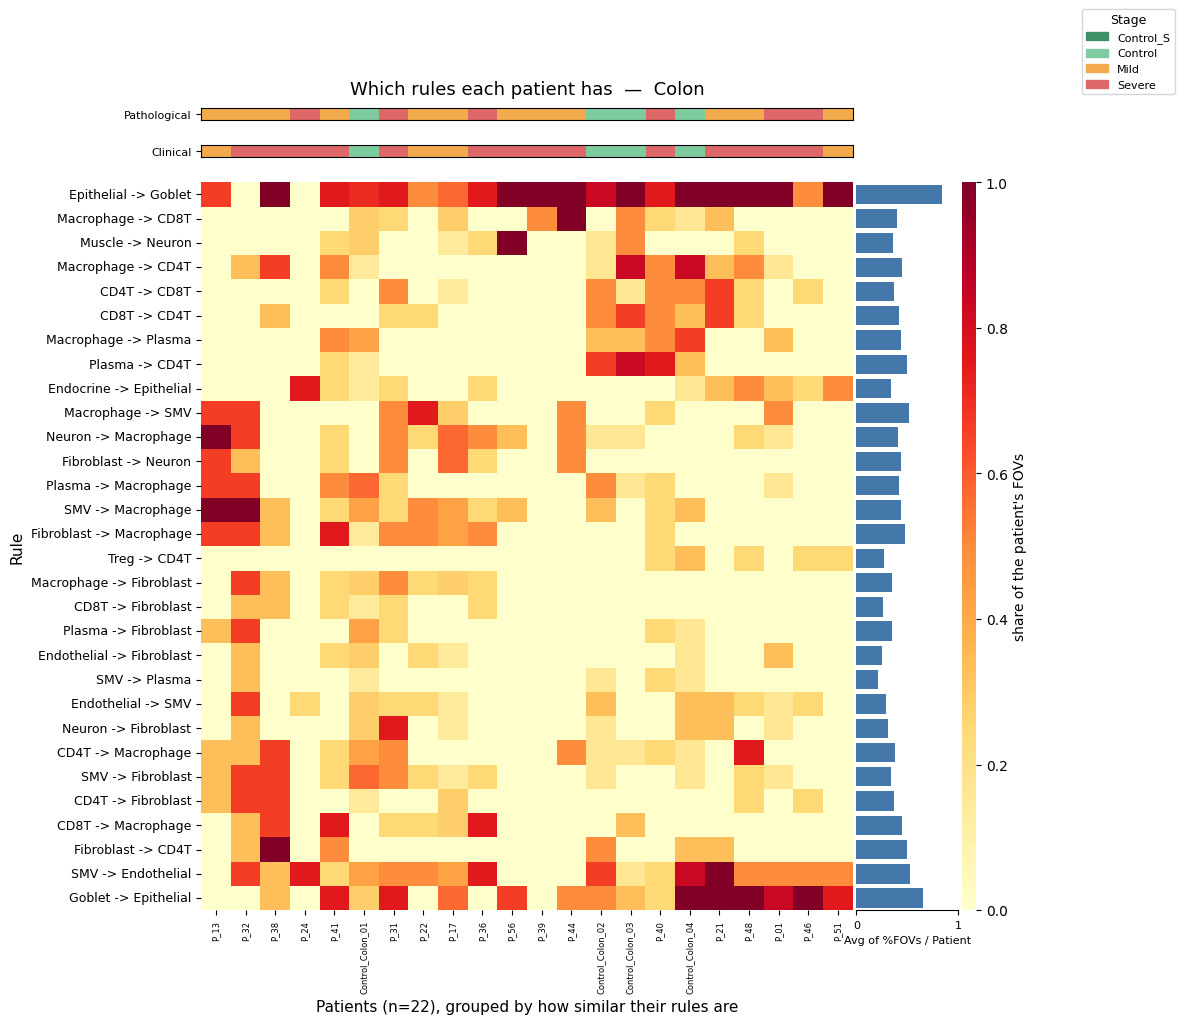

saved summary_downloads\q2_patient_fingerprint_duodenum.pdf


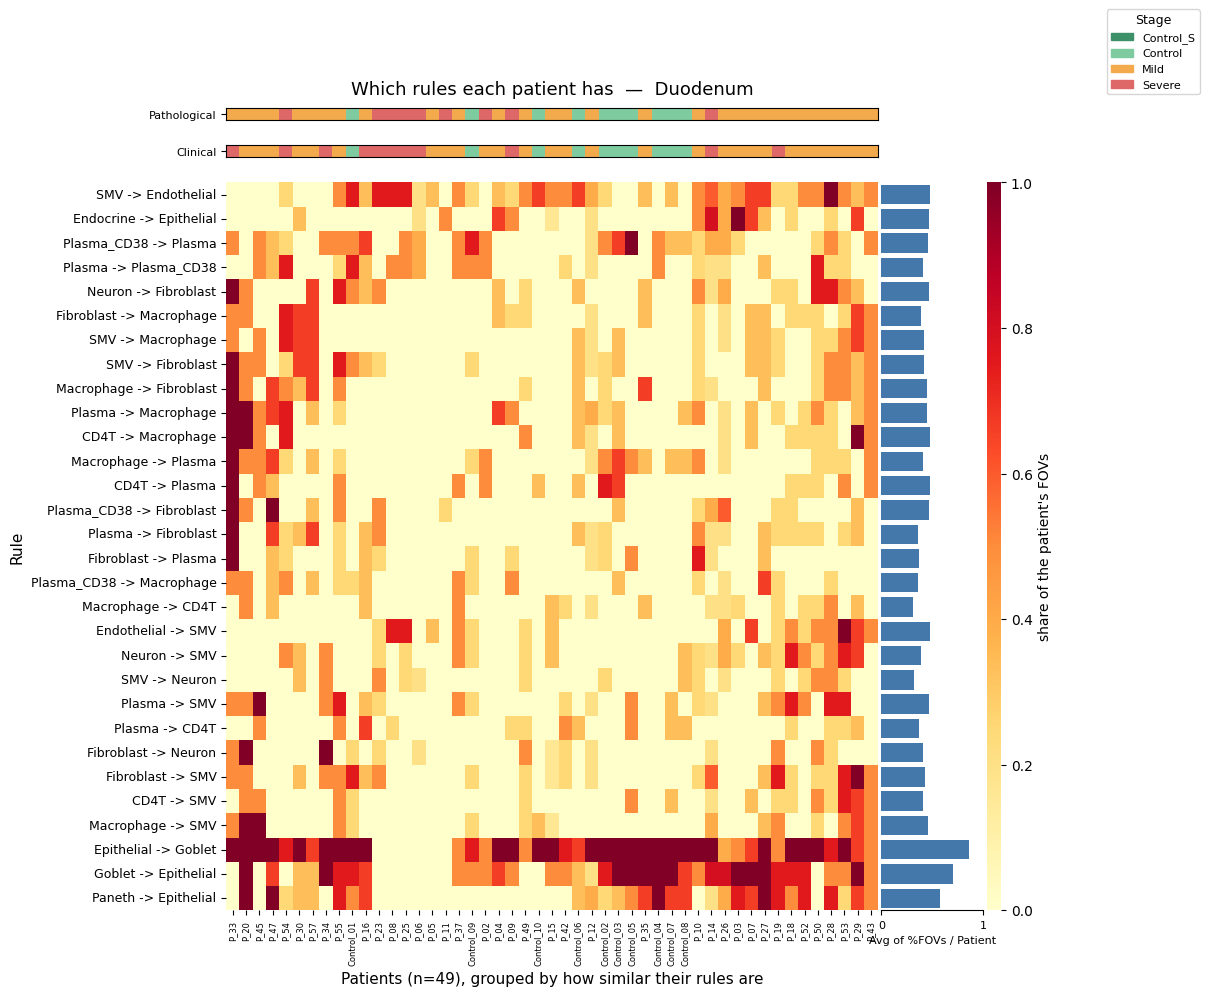

In [19]:
# Patients grouped by how similar their rules are (use order='stage' to sort by stage instead).
show_fingerprint(score_col='Pathological score', order='cluster', cluster_rules=True,
                 show_consistency=True, save='q2_patient_fingerprint')

# The same picture inside each organ, where the rule sets are different.
show_fingerprint(score_col='Pathological score', order='cluster', cluster_rules=True,
                 show_consistency=True, organs=['Colon'], save='q2_patient_fingerprint_colon')
show_fingerprint(score_col='Pathological score', order='cluster', cluster_rules=True,
                 show_consistency=True, organs=['Duodenum'], save='q2_patient_fingerprint_duodenum');


### Q3 — Rules that are strong and show up in more than one patient
The heatmap above picks rules mostly by how common they are, so their lift is low (~1.4). Here we
rank **all** rules by their own numbers instead — lift, conviction, confidence — and keep only the
ones found in **more than one patient**, because a rule seen in a single patient may just be that
one sample. `REPRO_COL` picks what to count: **change it to `'FOV'` or `'Biopsy'`** to count FOVs or
biopsies instead of patients. In the plot, dots to the **right** have higher lift, dots **up** have
higher conviction, and **bigger dots** are found in more patients — so top-right and big is what we
want. Only the strongest few are named on the plot; the table below lists exactly those. The second
plot is the same one, interactive — hover any dot for its rule and numbers.


330 rules total; 207 found in at least 2 patients.

saved summary_downloads\q3_lift_vs_conviction.pdf


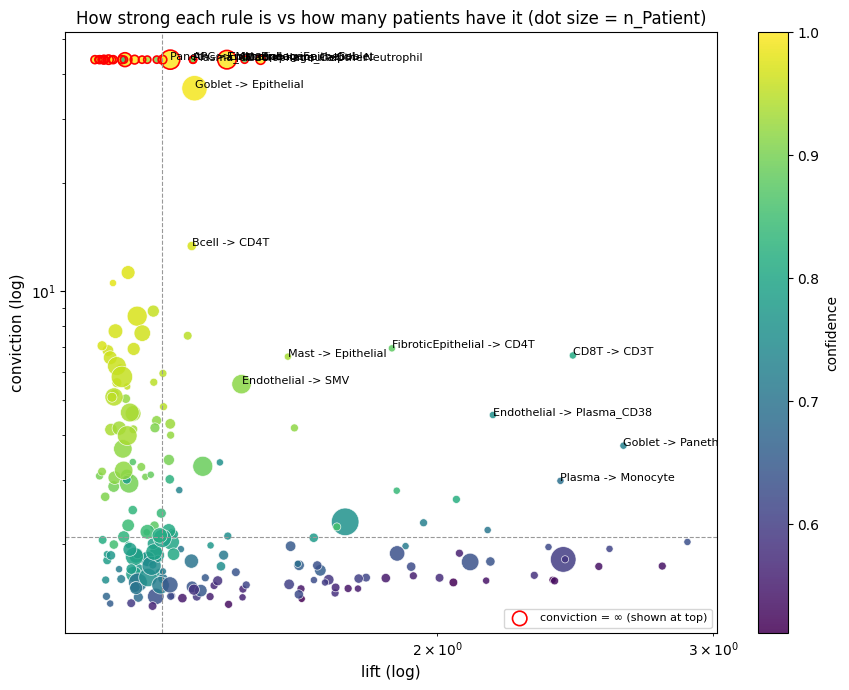

,antecedent,consequent,med_Lift,med_Confidence,med_Conviction,n_Patient,n_FOV,ant_abund,con_abund
Clean_Rule,,,,,,,,,
Goblet -> Paneth,Goblet,Paneth,2.629,0.725,3.739,2,2,0.013,0.090
CD8T -> CD3T,CD8T,CD3T,2.441,0.807,6.646,2,2,0.022,0.030
Plasma -> Monocyte,Plasma,Monocyte,2.397,0.692,2.988,2,2,0.025,0.015
Endothelial -> Plasma_CD38,Endothelial,Plasma_CD38,2.171,0.757,4.547,2,2,0.013,0.026
FibroticEpithelial -> CD4T,FibroticEpithelial,CD4T,1.872,0.879,6.955,2,2,0.017,0.061
Mast -> Epithelial,Mast,Epithelial,1.607,0.934,6.596,2,2,0.009,0.185
Endocrine -> Goblet,Endocrine,Goblet,1.544,1.000,inf,5,8,0.010,0.152
Macrophage_Calp -> Neutrophil,Macrophage_Calp,Neutrophil,1.508,0.879,inf,2,2,0.012,0.104
Endothelial -> SMV,Endothelial,SMV,1.501,0.915,5.535,30,54,0.016,0.076


In [20]:
# --- What to count: 'PatientID', or change to 'FOV' / 'Biopsy' ---
REPRO_COL = 'PatientID'
MIN_COUNT = 2          # keep rules found in at least this many patients (or FOVs / biopsies)
_count_col = {'FOV': 'n_FOV', 'Biopsy': 'n_Biopsy', 'PatientID': 'n_Patient'}[REPRO_COL]
_unit = {'FOV': 'FOVs', 'Biopsy': 'biopsies', 'PatientID': 'patients'}[REPRO_COL]

# One row per rule, over ALL rules (not just the ones the heatmap picked).
canon = canonicalize_rules(df_results)
rule_table = build_rule_table(canon, df_fovs, fov_frac=FOV_FRAC, with_abundance=True,
                              score_col='Pathological score')
repeated = rule_table[rule_table[_count_col] >= MIN_COUNT].copy()
print(f"{len(rule_table)} rules total; {len(repeated)} found in at least {MIN_COUNT} {_unit}.\n")

# The named rules are the strongest ones in the picture; the table lists exactly those.
named_rules = plot_rule_metric_scatter(repeated, size_col=_count_col, annotate_top=15,
                                       save='q3_lift_vs_conviction')
display(named_rules)

# Same plot, interactive: hover any dot for its rule and numbers.
plot_rule_metric_scatter_interactive(repeated, size_col=_count_col);


### Do the scores just follow how common the cell types are?
One figure per score. Each dot is **one rule in one FOV**: that FOV's own lift / confidence /
conviction, against how common the rule's cell types are **in that same FOV** (share of cells).
Nothing is averaged — the thick line is only a median-per-bin guide. **Left panel = antecedent,
right panel = consequent**, same y-axis, so you can see which side the score follows.


saved summary_downloads\q4_abundance_lift.pdf


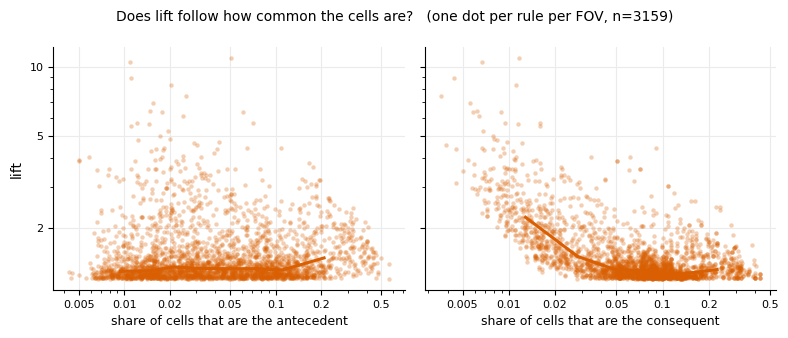

saved summary_downloads\q4_abundance_confidence.pdf


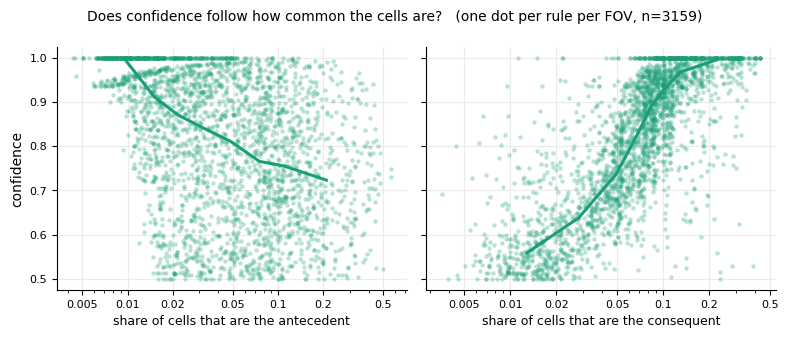

saved summary_downloads\q4_abundance_conviction.pdf


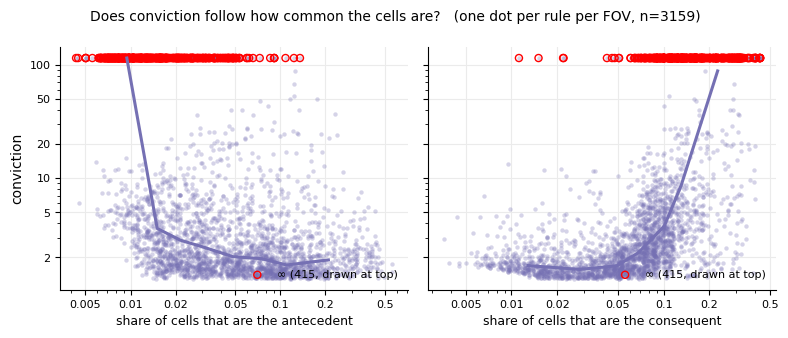

In [21]:
# One dot per rule per FOV. `canon` (all pairwise rules, one row per FOV) comes from the cell above.
for metric in ['Lift', 'Confidence', 'Conviction']:
    plot_metric_vs_abundance(canon, FOV_FRAC, metric=metric,
                             save=f'q4_abundance_{metric.lower()}')


### Top rules ordered by cell abundance (ant / con / both)
The same Q4 abundance figure, **re-sorted** so the highest-abundance rules sit on top
(`sort_by='ant' | 'con' | 'both'`) — the likeliest abundance artifacts. Below it, the most
abundance-driven rules across **all** canonical rules (not just the top-N).


saved summary_downloads\q4_prevalence_by_abundance.pdf


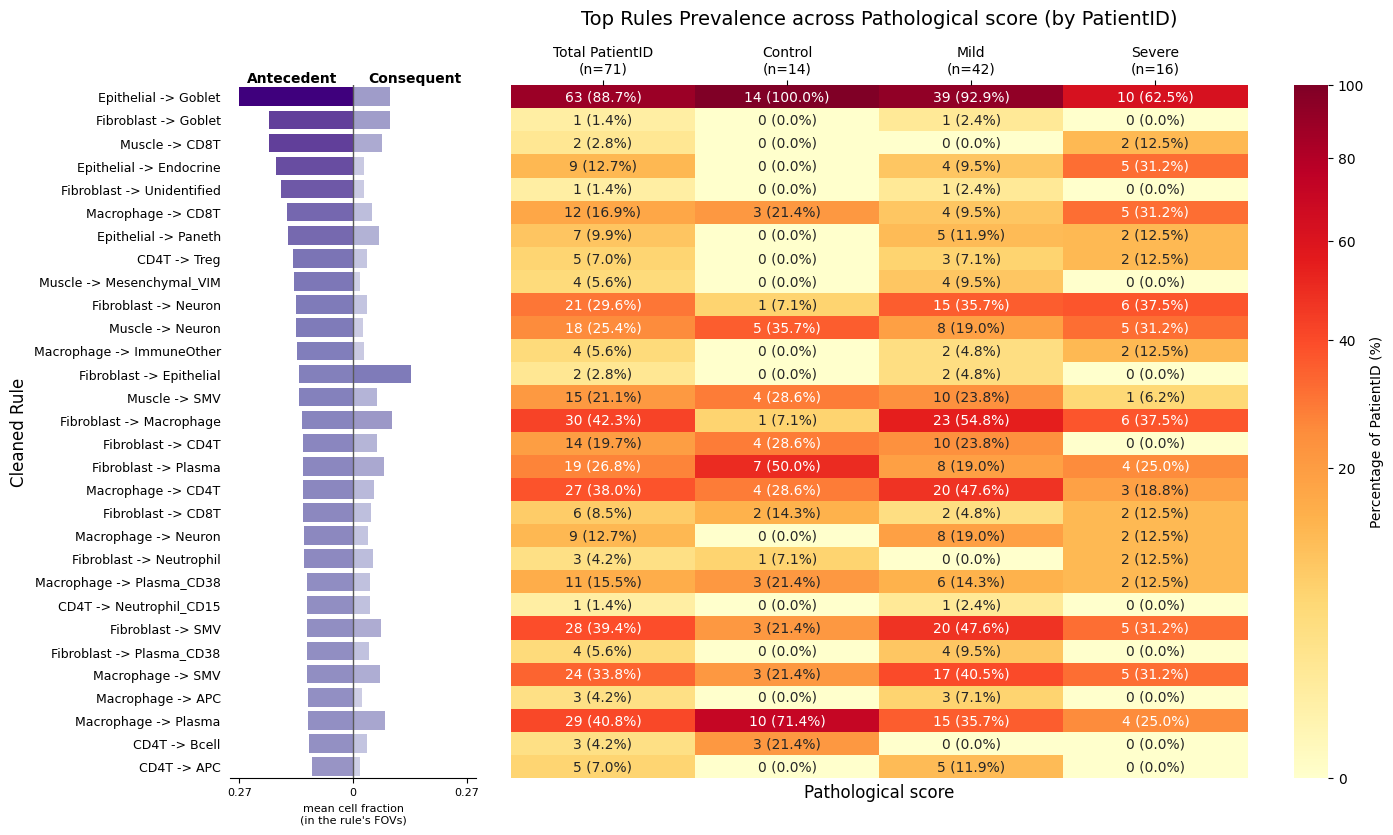

--- Top 10 rules by mean(ant, con) abundance (all rules) ---
                              antecedent  consequent  ant_abund  con_abund  n_Patient  med_Lift
Clean_Rule                                                                                     
Epithelial -> Goblet          Epithelial      Goblet      0.270      0.089         63     1.748
ImmuneOther -> Goblet        ImmuneOther      Goblet      0.011      0.347          1     1.254
Plasma_CD38 -> Epithelial    Plasma_CD38  Epithelial      0.016      0.288          6     1.241
Unidentified -> Epithelial  Unidentified  Epithelial      0.008      0.294          1     1.210
Goblet -> Epithelial              Goblet  Epithelial      0.070      0.229         53     1.401
Paneth -> Epithelial              Paneth  Epithelial      0.019      0.270         29     1.352
Fibroblast -> Goblet          Fibroblast      Goblet      0.200      0.087          1     1.365
SMV -> Epithelial                    SMV  Epithelial      0.020      0.259 

In [22]:
# Displayed top rules, re-ordered by antecedent abundance (try 'con' or 'both').
show_heatmap(score_col='Pathological score', id_col='PatientID', show_abundance=True, sort_by='ant',
             save='q4_prevalence_by_abundance')

# Most abundance-driven rules across ALL canonical rules:
_ranked = rule_table.assign(mean_abund=rule_table[['ant_abund', 'con_abund']].mean(axis=1))
print("--- Top 10 rules by mean(ant, con) abundance (all rules) ---")
print(_ranked.sort_values('mean_abund', ascending=False)
      .head(10)[['antecedent', 'consequent', 'ant_abund', 'con_abund', 'n_Patient', 'med_Lift']]
      .round(3).to_string())
